# Estado da Arte - Levantamento Bibliográfico

---

**Instituto Federal de Goiás – IFG**
**Programa de Pós-Graduação em Educação Profissional e Tecnológica – ProfEPT**
**Mestrado Profissional em Educação Profissional e Tecnológica**

**Pesquisador:** Marco Antônio Queiroz
**Orientadora:** Profa. Dra. Claudia Helena dos Santos Araujo
**Linha de pesquisa:** Práticas Educativas em Educação Profissional e Tecnológica (EPT)
**Anápolis – GO | 2026**

---

**PRÁTICAS COLABORATIVAS DE MEDIAÇÃO PEDAGÓGICA E LINGUÍSTICA ENTRE PROFESSORES E INTÉRPRETES NA EDUCAÇÃO PROFISSIONAL E TECNOLÓGICA: PROPOSIÇÃO DE UM AMBIENTE BILÍNGUE DE MEDIAÇÃO CONCEITUAL (PORTUGUÊS/LIBRAS)**

---

## Nota metodológica

Este notebook documenta o **Estado da Arte** da pesquisa, seguindo a abordagem proposta por Ferreira (2002) e Romanowski e Ens (2006), que caracterizam esse tipo de produção acadêmica como um inventário descritivo e analítico da produção científica sobre determinada temática, com o objetivo de identificar o que já foi investigado, como foi investigado e quais lacunas permanecem abertas.

O processo de levantamento seguiu protocolo sistemático de busca, triagem e seleção - documentado em fluxograma adaptado do modelo PRISMA (*Preferred Reporting Items for Systematic Reviews and Meta-Analyses*) -, organizado em quatro etapas:

1. **Identificação** - busca nas bases de dados com estratégias por eixo temático (Seção 1)
2. **Triagem formal** - aplicação dos critérios de inclusão e exclusão por tipo de material e período (Seção 2)
3. **Elegibilidade temática** - leitura de títulos e resumos com base nos critérios temáticos (Seção 2)
4. **Corpus final** - conjunto de trabalhos analisados por eixo e em perspectiva cruzada (Seções 3–7)

### Sobre a classificação por eixo temático: decisão metodológica, não algorítmica

A classificação de cada trabalho em um ou mais eixos temáticos **não resultou de processo automatizado**, mas de decisão interpretativa do pesquisador, realizada após leitura dos títulos, resumos e palavras-chave de cada registro. Trata-se de uma operação metodológica intencional, orientada pelos objetivos da pesquisa e pelos critérios descritos na Seção 2.

Esse procedimento segue a tradição das pesquisas do tipo "estado da arte" nas Ciências Humanas (FERREIRA, 2002; ROMANOWSKI; ENS, 2006), nas quais a categorização temática é ato de pesquisa - implicando escolhas analíticas sustentadas pelo referencial teórico -, e não mera triagem automatizada. A explicitação dos critérios de cada eixo (Seção 1.2) permite que outros pesquisadores acompanhem, repliquem ou questionem as escolhas realizadas, garantindo o requisito de transparência metodológica.

Os dados brutos do levantamento estão organizados no arquivo `data/pesquisa.xlsx`, disponibilizado como dado suplementar desta pesquisa¹. Este notebook constitui o **instrumento de análise e visualização** dos dados - não uma fonte bibliográfica primária de revisão de literatura. As sínteses analíticas produzidas a partir dele são incorporadas ao corpo do texto da dissertação com as devidas referências aos trabalhos mapeados.

---
> ¹ O conjunto de dados e o script de análise estão disponíveis em: QUEIROZ, M. A. *ProfEPT: estado da arte - dados e análise*. Anápolis: IFG, 2026. Disponível em: https://marcoantonioq.github.io/profept/arte/. Acesso em: 6 jul. 2026. (Dado suplementar; não constitui fonte bibliográfica primária.)

> **Referências metodológicas:**
> FERREIRA, N. S. A. As pesquisas denominadas "estado da arte". *Educação & Sociedade*, Campinas, v. 23, n. 79, p. 257–272, ago. 2002.
> ROMANOWSKI, J. P.; ENS, R. T. As pesquisas denominadas do tipo "estado da arte" em educação. *Diálogo Educacional*, Curitiba, v. 6, n. 19, p. 37–50, 2006.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
ACCENT  = '#1a5276'
PAL     = ['#2980b9','#e74c3c','#27ae60','#9b59b6','#f39c12','#95a5a6']
EIXOS   = ['Eixo 1','Eixo 2','Eixo 3','Eixo 4','Eixo 5']
EIXO_FULL = {
    'Eixo 1': 'Eixo 1 - Educação de surdos + mediação',
    'Eixo 2': 'Eixo 2 - Educação de surdos + professor/intérprete',
    'Eixo 3': 'Eixo 3 - Educação de surdos + colaboração',
    'Eixo 4': 'Eixo 4 - Educação de surdos + tecnologias',
    'Eixo 5': 'Eixo 5 - Educação Profissional e Tecnológica',
}

# Carregamento
conn = sqlite3.connect('data/data.sqlite')
df_raw = pd.read_sql_query("SELECT * FROM pesquisa", conn)
conn.close()

df_raw['Ano'] = pd.to_numeric(df_raw['Ano'], errors='coerce')

TIPO_MAP = {
    'masterThesis': 'Dissertação',
    'Dissertação (Mestrado)': 'Dissertação',
    'Produto Educacional / Dissertação': 'Dissertação',
    'doctoralThesis': 'Tese',
    'Artigo Científico': 'Artigo',
    'Artigo (Anais de Evento Científico)': 'Artigo',
}
df_raw['Tipo'] = df_raw['Tipo de Material'].map(
    lambda x: TIPO_MAP.get(str(x).strip(), str(x).strip()) if pd.notna(x) else ''
)

def norm_str(v, vazio='Não identificado'):
    if pd.isna(v) or str(v).strip().lower() in ('nan', '', 'none'):
        return vazio
    return str(v).strip()

df_raw['nivel_ensino']     = df_raw['nivel_ensino'].apply(norm_str)
df_raw['tipo_artefato']    = df_raw['tipo_artefato'].apply(norm_str)
df_raw['tipo_estudo']      = df_raw['tipo_estudo'].apply(norm_str)
df_raw['Região do Brasil'] = df_raw['Região do Brasil'].apply(
    lambda x: norm_str(x, 'Não informada').replace('Não identificado', 'Não informada')
)

print(f"Base carregada: {len(df_raw):,} registros | {len(df_raw.columns)} colunas")
print(f"\nCampos enriquecidos - cobertura no banco completo:")
for c, label in [
    ('nivel_ensino',         'nivel_ensino (inferido por kw)'),
    ('tipo_estudo',          'tipo_estudo  (manual + inferido)'),
    ('tipo_artefato',        'tipo_artefato (Eixo 4, inferido)'),
    ('Região do Brasil',     'Região do Brasil (inst. + manual)'),
    ('Sujeitos da Pesquisa', 'Sujeitos da Pesquisa (manual)'),
]:
    preench = (~df_raw[c].replace('','Não identificado').fillna('Não identificado')
               .isin(['Não identificado','Não informada'])).sum()
    pct = preench/len(df_raw)*100
    print(f"  {label:<38} {preench:>5}/{len(df_raw):,} ({pct:.0f}%)")


Base carregada: 2,618 registros | 40 colunas

Campos enriquecidos - cobertura no banco completo:
  nivel_ensino (inferido por kw)          1333/2,618 (51%)
  tipo_estudo  (manual + inferido)        1130/2,618 (43%)
  tipo_artefato (Eixo 4, inferido)        2618/2,618 (100%)
  Região do Brasil (inst. + manual)       1948/2,618 (74%)
  Sujeitos da Pesquisa (manual)           1919/2,618 (73%)


## 1. Protocolo de Busca

### 1.1 Bases de dados, período e descritores

O levantamento foi realizado nas bases **BDTD (IBICT)** e **Catálogo de Teses e Dissertações da CAPES**, abrangendo produções do período **2020–2026**. Esse recorte temporal delimita a produção mais recente sobre os temas investigados, privilegiando a literatura contemporânea e o contexto pós-pandemia - período em que as práticas de mediação pedagógica e acessibilidade na educação de surdos passaram por transformações e reposicionamentos que ainda se consolidam na literatura acadêmica.

A estratégia de busca foi organizada em **cinco eixos temáticos** que estruturam o estado da arte conforme os objetivos da pesquisa. Para cada eixo foram elaborados descritores específicos, combinados com operadores booleanos (AND, OR) e truncamentos (*), de forma a garantir abrangência sem perda de especificidade.

### 1.2 Eixos temáticos: critérios de definição e processo de classificação

Os cinco eixos não foram gerados por algoritmo, mas **definidos previamente pelo pesquisador** com base nos objetivos específicos da pesquisa e no referencial teórico-metodológico adotado. Cada eixo corresponde a uma dimensão analítica distinta do problema de pesquisa, permitindo mapear a literatura de forma progressiva - do mais amplo (base conceitual da mediação) ao mais específico (EPT e Institutos Federais).

A **classificação de cada trabalho** em um eixo resultou de leitura e análise interpretativa do pesquisador. Um mesmo trabalho pode ser atribuído a mais de um eixo quando seu conteúdo contempla simultaneamente mais de uma das dimensões investigadas - o que representa, analiticamente, maior integração temática com o objeto desta pesquisa.

| Eixo | Foco temático | Justificativa para a pesquisa | Critério de classificação |
|------|--------------|-------------------------------|---------------------------|
| **Eixo 1** | Educação de surdos + mediação | Base conceitual da mediação pedagógica e linguística (Vigotski; Saviani) | Presença explícita de processos mediadores no contexto de surdos, independentemente do nível de ensino |
| **Eixo 2** | Educação de surdos + professor + intérprete | **Núcleo central** - relação professor-intérprete em contextos bilíngues | Investigações que têm professor e/ou intérprete como sujeitos ou foco, articulados a práticas de mediação |
| **Eixo 3** | Educação de surdos + colaboração | Dimensão colaborativa: coplanejamento e organização conjunta | Estudos sobre trabalho conjunto, codocência ou coplanejamento envolvendo surdos |
| **Eixo 4** | Educação de surdos + tecnologias | Fundamentação do Produto Educacional (PE) digital bilíngue | Presença de artefato tecnológico (software, plataforma, aplicativo) voltado à educação de surdos |
| **Eixo 5** | Educação Profissional e Tecnológica | Contexto específico da investigação - EPT e Institutos Federais | Foco explícito em EPT, ensino técnico, Instituto Federal ou contexto profissionalizante com surdos |

> **Nota de transparência:** Os critérios acima foram definidos *antes* do início da triagem temática e mantidos sem alteração durante todo o processo, seguindo exigência metodológica de prevenção do viés de seleção *a posteriori*.

In [2]:
# Estratégias de busca utilizadas por eixo
ESTRATEGIAS = {
    'Eixo 1': (
        '(surd* OR Libras OR "Língua Brasileira de Sinais") '
        'AND (mediação OR "mediação pedagógica" OR "mediação linguística" '
        'OR "mediação conceitual" OR "transposição didática")'
    ),
    'Eixo 2': (
        '(professor OR docente OR educador OR TILS OR intérprete OR "intérprete de Libras") '
        'AND (surdo OR surdez OR Libras OR "educação bilíngue" OR "comunidade surda" OR "estudante surdo") '
        'AND ("mediação pedagógica" OR "mediação linguística" OR "circulação de conhecimentos" '
        'OR "construção compartilhada de significados" OR "mediação conceitual" '
        'OR "interação pedagógica" OR "ensino colaborativo" OR colaboração '
        'OR codocência OR coplanejamento OR "formação conceitual")'
    ),
    'Eixo 3': (
        '(surdo OR surdez OR Libras OR "Língua Brasileira de Sinais") '
        'AND (colaboração OR "ensino colaborativo" OR codocência OR coplanejamento '
        'OR "trabalho colaborativo" OR "prática colaborativa")'
    ),
    'Eixo 4': (
        '(surdo OR surdez OR Libras OR "Língua Brasileira de Sinais") '
        'AND (software OR aplicativo OR plataforma OR "ambiente digital" '
        'OR "tecnologia educacional" OR "recurso digital" OR hipermídia '
        'OR PWA OR "aplicativo web" OR "tecnologia assistiva")'
    ),
    'Eixo 5': (
        '(surdo OR surdez OR Libras OR "intérprete") '
        'AND ("educação profissional" OR EPT OR "ensino técnico" '
        'OR "Instituto Federal" OR IFET OR "rede federal")'
    ),
}

print("ESTRATÉGIAS DE BUSCA POR EIXO TEMÁTICO")
print("=" * 70)
for eixo, descr in ESTRATEGIAS.items():
    full = EIXO_FULL[eixo]
    print(f"\n{full}")
    print("-" * len(full))
    # Quebrar em linhas para leitura
    palavras = descr.split()
    linha, linhas = "", []
    for p in palavras:
        if len(linha) + len(p) + 1 > 78:
            linhas.append(linha)
            linha = p
        else:
            linha = (linha + " " + p).strip()
    if linha: linhas.append(linha)
    print("  " + "\n  ".join(linhas))


ESTRATÉGIAS DE BUSCA POR EIXO TEMÁTICO

Eixo 1 - Educação de surdos + mediação
--------------------------------------
  (surd* OR Libras OR "Língua Brasileira de Sinais") AND (mediação OR "mediação
  pedagógica" OR "mediação linguística" OR "mediação conceitual" OR
  "transposição didática")

Eixo 2 - Educação de surdos + professor/intérprete
--------------------------------------------------
  (professor OR docente OR educador OR TILS OR intérprete OR "intérprete de
  Libras") AND (surdo OR surdez OR Libras OR "educação bilíngue" OR "comunidade
  surda" OR "estudante surdo") AND ("mediação pedagógica" OR "mediação
  linguística" OR "circulação de conhecimentos" OR "construção compartilhada de
  significados" OR "mediação conceitual" OR "interação pedagógica" OR "ensino
  colaborativo" OR colaboração OR codocência OR coplanejamento OR "formação
  conceitual")

Eixo 3 - Educação de surdos + colaboração
-----------------------------------------
  (surdo OR surdez OR Libras OR "Língua Bra

## 2. Critérios de Inclusão e Exclusão

Os critérios foram definidos **previamente ao processo de busca** - exigência metodológica que previne o viés de seleção a posteriori -, orientados pelo problema e pelos objetivos da pesquisa. Foram aplicados em duas etapas sequenciais: a primeira sobre tipo de material e período (triagem formal); a segunda sobre pertinência temática, por meio da leitura de títulos e resumos (triagem temática).

### Critérios de inclusão

1. Teses e dissertações disponíveis integralmente nas bases consultadas
2. Produções publicadas no período **2020–2026**
3. Relação direta com processos educativos envolvendo **estudantes surdos**
4. Presença de **professores**, **intérpretes educacionais** ou ambos como sujeitos ou foco da investigação
5. Enfoque em **mediação pedagógica**, **mediação linguística** ou **recursos digitais** em contextos educacionais bilíngues

### Critérios de exclusão

1. Estudos de natureza predominantemente **clínica, terapêutica ou audiológica**
2. Pesquisas **sem relação com processos educativos formais** (escolarização, formação profissional)
3. Trabalhos centrados exclusivamente no **desempenho individual do estudante**, sem articulação com práticas de mediação
4. Produções **sem aderência ao problema e aos objetivos** desta investigação, identificada após leitura do resumo
5. Artigos, livros, legislação e outros materiais que **não sejam teses ou dissertações**

In [3]:
# ── Calcular cada etapa do funil ─────────────────────────────────────────────
TIPOS_INCLUSOS = {
    'Dissertação','Tese','masterThesis','doctoralThesis',
    'Dissertação (Mestrado)','Produto Educacional / Dissertação'
}

total_bruto      = len(df_raw)
n_bdtd           = (df_raw['Fonte/Base de Dados'] == 'BDTD (IBICT)').sum()
n_capes          = (df_raw['Fonte/Base de Dados'] == 'Catálogo de Teses CAPES').sum()
n_repo           = (df_raw['Fonte/Base de Dados'] == 'Repositório Institucional').sum()
n_sem_fonte      = total_bruto - n_bdtd - n_capes - n_repo   # registros sem fonte registrada no banco

mask_tipo        = df_raw['Tipo de Material'].isin(TIPOS_INCLUSOS)
n_excluidos_tipo = (~mask_tipo).sum()

mask_periodo     = (df_raw['Ano'] >= 2020) & (df_raw['Ano'] <= 2026)
n_excluidos_periodo = (mask_tipo & ~mask_periodo).sum()

mask_triagem     = mask_tipo & mask_periodo
n_apos_triagem   = mask_triagem.sum()

mask_eixo        = df_raw['Eixo'].notna() & (df_raw['Eixo'].str.strip() != '')
mask_excl_tematica = mask_triagem & ~mask_eixo
n_excl_tematica  = mask_excl_tematica.sum()

mask_corpus      = mask_triagem & mask_eixo
n_corpus         = mask_corpus.sum()

# Corpus final
df_corpus = df_raw[mask_corpus].copy()

print("PROCESSO DE SELEÇÃO - SÍNTESE QUANTITATIVA")
print("=" * 55)
print(f"  Base BDTD (IBICT):                        {n_bdtd:>5,}")
print(f"  Catálogo de Teses CAPES:                  {n_capes:>5,}")
if n_repo > 0:
    print(f"  Repositório Institucional:                {n_repo:>5,}")
if n_sem_fonte > 0:
    print(f"  Fonte não registrada:                     {n_sem_fonte:>5,}")
print(f"  {'─'*42}")
print(f"  Total bruto recuperado:                   {total_bruto:>5,}")
print()
print(f"  (−) Excluídos: não são teses/dissertações:{n_excluidos_tipo:>5,}")
print(f"  (−) Excluídos: fora do período 2020–2026: {n_excluidos_periodo:>5,}")
print(f"  {'─'*42}")
print(f"  Após triagem formal (tipo + período):     {n_apos_triagem:>5,}")
print()
print(f"  (−) Excluídos: triagem temática           {n_excl_tematica:>5,}")
print(f"       (títulos/resumos sem pertinência)")
print(f"  {'─'*42}")
print(f"  CORPUS FINAL (classificado por eixo):     {n_corpus:>5,}")
print()
print("  Distribuição do corpus por eixo:")
for e in EIXOS:
    n = df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum()
    print(f"    {EIXO_FULL[e]}: {n}")

multi = (df_corpus['Eixo'].str.contains('|', regex=False, na=False)).sum()
print(f"\n  Registros classificados em múltiplos eixos: {multi}")
print(f"  (um mesmo trabalho pode aparecer em mais de um eixo)")

PROCESSO DE SELEÇÃO - SÍNTESE QUANTITATIVA
  Base BDTD (IBICT):                          693
  Catálogo de Teses CAPES:                  1,820
  Repositório Institucional:                  105
  ──────────────────────────────────────────
  Total bruto recuperado:                   2,618

  (−) Excluídos: não são teses/dissertações:   23
  (−) Excluídos: fora do período 2020–2026:     1
  ──────────────────────────────────────────
  Após triagem formal (tipo + período):     2,594

  (−) Excluídos: triagem temática           1,728
       (títulos/resumos sem pertinência)
  ──────────────────────────────────────────
  CORPUS FINAL (classificado por eixo):       866

  Distribuição do corpus por eixo:
    Eixo 1 - Educação de surdos + mediação: 146
    Eixo 2 - Educação de surdos + professor/intérprete: 326
    Eixo 3 - Educação de surdos + colaboração: 221
    Eixo 4 - Educação de surdos + tecnologias: 444
    Eixo 5 - Educação Profissional e Tecnológica: 46

  Registros classificados em 

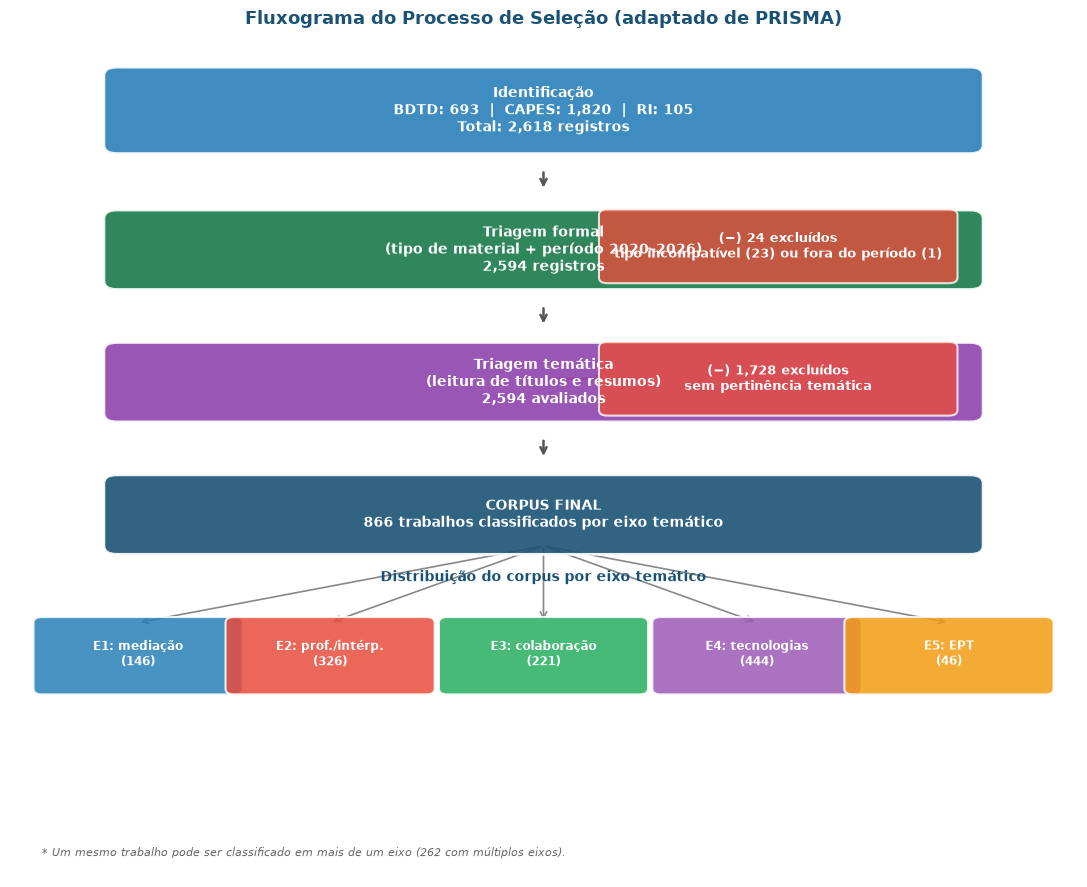

FLUXOGRAMA DE SELEÇÃO (adaptado de PRISMA)
  [IDENTIFICAÇÃO]
    BDTD (IBICT):                  693
    Catálogo de Teses CAPES:     1,820
    Repositório Institucional:     105
    TOTAL bruto recuperado:      2,618

  [TRIAGEM FORMAL]
    (-) Tipo incompatível:          23
    (-) Fora do período:             1
    Após triagem formal:         2,594

  [TRIAGEM TEMÁTICA]
    (-) Sem pertinência:         1,728

  [CORPUS FINAL]                 866
  Distribuição por eixo:
    Eixo 1 - Educação de surdos + mediação            146 (17%)
    Eixo 2 - Educação de surdos + professor/intérprete  326 (38%)
    Eixo 3 - Educação de surdos + colaboração         221 (26%)
    Eixo 4 - Educação de surdos + tecnologias         444 (51%)
    Eixo 5 - Educação Profissional e Tecnológica       46 (5%)
  Registros em multiplos eixos: 262


In [4]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('Fluxograma do Processo de Seleção (adaptado de PRISMA)',
             fontsize=13, fontweight='bold', color=ACCENT, pad=12)

def box(ax, x, y, w, h, text, color, fontsize=10):
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.12", facecolor=color,
        edgecolor='white', linewidth=2, alpha=0.90, zorder=3
    )
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            color='white', fontweight='bold', zorder=4, wrap=True,
            multialignment='center')

def seta(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2 + 0.35), xytext=(x1, y1 - 0.35),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=2)

def box_excl(ax, x, y, text):
    rect = mpatches.FancyBboxPatch(
        (x, y - 0.4), 3.2, 0.9,
        boxstyle="round,pad=0.08", facecolor='#e74c3c',
        edgecolor='white', linewidth=1.5, alpha=0.80, zorder=3
    )
    ax.add_patch(rect)
    ax.text(x + 1.6, y + 0.05, text, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold', zorder=4)
    ax.annotate('', xy=(x, y + 0.05), xytext=(5, y + 0.05),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5), zorder=2)

# Caixas principais (eixo central x=5)
src_txt = f'BDTD: {n_bdtd:,}  |  CAPES: {n_capes:,}' + (f'  |  RI: {n_repo:,}' if n_repo > 0 else '') + (f'  |  n/d: {n_sem_fonte:,}' if n_sem_fonte > 0 else '')
box(ax, 5, 11,  8, 1.0,
    f'Identificação\n{src_txt}\nTotal: {total_bruto:,} registros',
    '#2980b9')
seta(ax, 5, 10.5, 5, 9.5)

box(ax, 5, 9,   8, 0.9,
    f'Triagem formal\n(tipo de material + período 2020–2026)\n{n_apos_triagem:,} registros',
    '#1a7a4a')
seta(ax, 5, 8.55, 5, 7.55)

box(ax, 5, 7.1, 8, 0.9,
    f'Triagem temática\n(leitura de títulos e resumos)\n{n_apos_triagem:,} avaliados',
    '#8e44ad')
seta(ax, 5, 6.65, 5, 5.65)

box(ax, 5, 5.2, 8, 0.9,
    f'CORPUS FINAL\n{n_corpus:,} trabalhos classificados por eixo temático',
    ACCENT)

# Caixas de exclusão (direita)
box_excl(ax, 5.6, 9.0,
         f'(−) {n_excluidos_tipo + n_excluidos_periodo:,} excluídos\n'
         f'tipo incompatível ({n_excluidos_tipo}) ou fora do período ({n_excluidos_periodo})')
box_excl(ax, 5.6, 7.1,
         f'(−) {n_excl_tematica:,} excluídos\nsem pertinência temática')

# Decomposição por eixo
y_eixo = 3.8
ax.text(5, y_eixo + 0.5, 'Distribuição do corpus por eixo temático',
        ha='center', va='center', fontsize=10, color=ACCENT, fontweight='bold')
nomes_curtos = ['E1: mediação','E2: prof./intérp.','E3: colaboração','E4: tecnologias','E5: EPT']
ns_eixo = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
xs = [1.2, 3.0, 5.0, 7.0, 8.8]
for xi, nome, ni, cor in zip(xs, nomes_curtos, ns_eixo, PAL):
    rect = mpatches.FancyBboxPatch(
        (xi - 0.9, y_eixo - 1.1), 1.8, 0.95,
        boxstyle="round,pad=0.08", facecolor=cor, edgecolor='white',
        linewidth=1.5, alpha=0.85, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xi, y_eixo - 0.6, f'{nome}\n({ni})', ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold', zorder=4)
    ax.annotate('', xy=(xi, y_eixo - 0.15), xytext=(5, 4.75),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2), zorder=2)

ax.text(0.3, 0.3, f'* Um mesmo trabalho pode ser classificado em mais de um eixo ({multi} com múltiplos eixos).',
        fontsize=8, color='#666', style='italic')

plt.tight_layout()
plt.savefig('data/fig_fluxograma_selecao.png', dpi=150, bbox_inches='tight')
plt.show()

# Saida textual do fluxograma
sep = "=" * 55
print(sep)
print("FLUXOGRAMA DE SELEÇÃO (adaptado de PRISMA)")
print(sep)
print(f"  [IDENTIFICAÇÃO]")
print(f"    BDTD (IBICT):                {n_bdtd:>5,}")
print(f"    Catálogo de Teses CAPES:     {n_capes:>5,}")
if n_repo > 0:
    print(f"    Repositório Institucional:   {n_repo:>5,}")
if n_sem_fonte > 0:
    print(f"    Fonte não registrada:        {n_sem_fonte:>5,}")
print(f"    TOTAL bruto recuperado:      {total_bruto:>5,}")
print()
print(f"  [TRIAGEM FORMAL]")
print(f"    (-) Tipo incompatível:       {n_excluidos_tipo:>5,}")
print(f"    (-) Fora do período:         {n_excluidos_periodo:>5,}")
print(f"    Após triagem formal:         {n_apos_triagem:>5,}")
print()
print(f"  [TRIAGEM TEMÁTICA]")
print(f"    (-) Sem pertinência:         {n_excl_tematica:>5,}")
print()
print(f"  [CORPUS FINAL]               {n_corpus:>5,}")
print(sep)
print("  Distribuição por eixo:")
for e in EIXOS:
    n = df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum()
    pct = n/n_corpus*100
    print(f"    {EIXO_FULL[e]:<48} {n:>4} ({pct:.0f}%)")
print(f"  Registros em multiplos eixos: {multi}")
print(sep)


## 3. Panorama do Corpus

Caracterização geral dos trabalhos que compõem o corpus final, considerando base de dados de origem, tipo de material, distribuição temporal, região geográfica e instituição de vinculação.


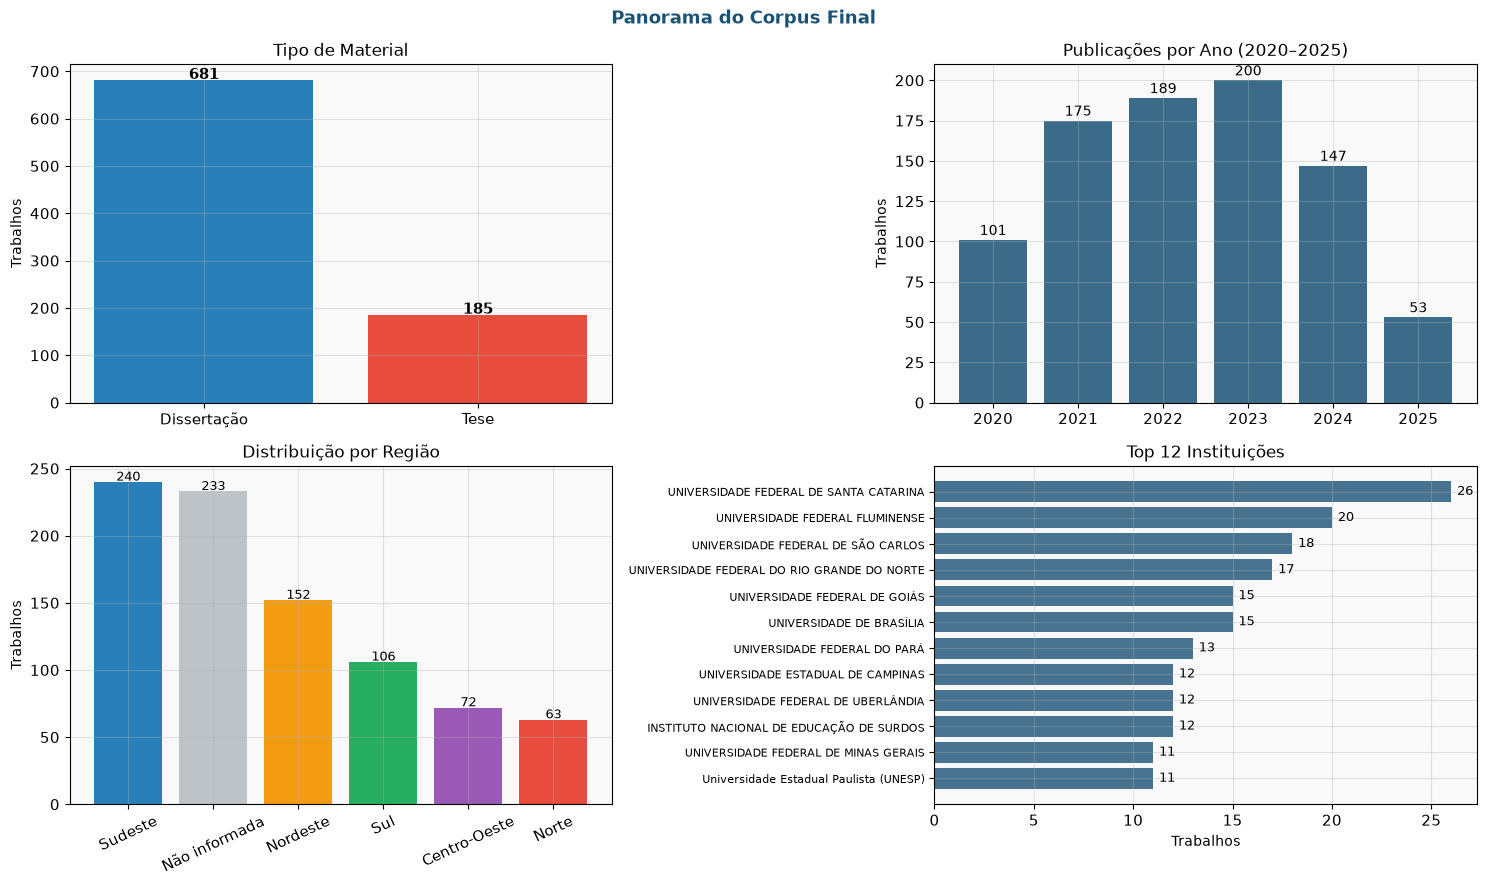


PANORAMA DO CORPUS FINAL

  TIPO DE MATERIAL (total=866):
     681 (  79%)  Dissertação
     185 (  21%)  Tese

  PUBLICAÇÕES POR ANO (2020-2025):
    2020:  101 (  12%)
    2021:  175 (  20%)
    2022:  189 (  22%)
    2023:  200 (  23%)
    2024:  147 (  17%)
    2025:   53 (   6%)

  DISTRIBUIÇÃO REGIONAL (total=866):
     240 (  28%)  Sudeste
     233 (  27%)  Não informada
     152 (  18%)  Nordeste
     106 (  12%)  Sul
      72 (   8%)  Centro-Oeste
      63 (   7%)  Norte

  TOP 15 INSTITUIÇÕES:
      26 (   3%)  UNIVERSIDADE FEDERAL DE SANTA CATARINA
      20 (   2%)  UNIVERSIDADE FEDERAL FLUMINENSE
      18 (   2%)  UNIVERSIDADE FEDERAL DE SÃO CARLOS
      17 (   2%)  UNIVERSIDADE FEDERAL DO RIO GRANDE DO NORTE
      15 (   2%)  UNIVERSIDADE FEDERAL DE GOIÁS
      15 (   2%)  UNIVERSIDADE DE BRASÍLIA
      13 (   2%)  UNIVERSIDADE FEDERAL DO PARÁ
      12 (   1%)  UNIVERSIDADE ESTADUAL DE CAMPINAS
      12 (   1%)  UNIVERSIDADE FEDERAL DE UBERLÂNDIA
      12 (   1%)  INSTITU

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Panorama do Corpus Final', fontsize=13, fontweight='bold', color=ACCENT)

# 1. Distribuição por tipo de material
tipo_c = df_corpus['Tipo'].replace('','Não inf.').fillna('Não inf.').value_counts()
tipo_c = tipo_c[tipo_c.index.isin(['Dissertação','Tese'])]
axes[0,0].bar(tipo_c.index, tipo_c.values, color=[PAL[0], PAL[1]])
axes[0,0].set_title('Tipo de Material')
axes[0,0].set_ylabel('Trabalhos')
for i, v in enumerate(tipo_c.values):
    axes[0,0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=11)

# 2. Distribuição anual (2020–2025)
ano_foco = df_corpus[(df_corpus['Ano'] >= 2020) & (df_corpus['Ano'] <= 2025)]
ano_c = ano_foco.groupby('Ano').size()
bars = axes[0,1].bar(ano_c.index, ano_c.values, color=ACCENT, alpha=0.85)
axes[0,1].set_title('Publicações por Ano (2020–2025)')
axes[0,1].set_ylabel('Trabalhos')
axes[0,1].set_xticks(range(2020, 2026))
for bar, v in zip(bars, ano_c.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
                   ha='center', va='bottom', fontsize=10)

# 3. Distribuição regional
reg_c = df_corpus['Região do Brasil'].replace('','Não informada').fillna('Não informada').value_counts()
cores_reg = {'Sudeste':'#2980b9','Sul':'#27ae60','Nordeste':'#f39c12',
             'Centro-Oeste':'#9b59b6','Norte':'#e74c3c','Não informada':'#bdc3c7','Nacional':'#95a5a6'}
cores_r = [cores_reg.get(r,'#bdc3c7') for r in reg_c.index]
axes[1,0].bar(reg_c.index, reg_c.values, color=cores_r)
axes[1,0].set_title('Distribuição por Região')
axes[1,0].set_ylabel('Trabalhos')
axes[1,0].tick_params(axis='x', rotation=25)
for i, v in enumerate(reg_c.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontsize=9)

# 4. Top 12 Instituições
inst_c = df_corpus['Instituição'].replace('','Não inf.').fillna('Não inf.')
inst_c = inst_c[inst_c != 'Não inf.'].value_counts().head(12)
axes[1,1].barh(inst_c.index[::-1], inst_c.values[::-1], color=ACCENT, alpha=0.8)
axes[1,1].set_title('Top 12 Instituições')
axes[1,1].set_xlabel('Trabalhos')
axes[1,1].set_yticklabels([i[:45] for i in inst_c.index[::-1]], fontsize=8)
for i, v in enumerate(inst_c.values[::-1]):
    axes[1,1].text(v + 0.3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/fig_panorama_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

diss = (df_corpus['Tipo']=='Dissertação').sum()
tese = (df_corpus['Tipo']=='Tese').sum()


# Saida textual completa do panorama
sep = "=" * 55
print()
print(sep)
print("PANORAMA DO CORPUS FINAL")
print(sep)

print(f"\n  TIPO DE MATERIAL (total={n_corpus}):")
tipo_all = df_corpus['Tipo'].replace('','Outro').fillna('Outro').value_counts()
for t, v in tipo_all.items():
    print(f"    {v:>4} ({v/n_corpus*100:4.0f}%)  {t}")

print(f"\n  PUBLICAÇÕES POR ANO (2020-2025):")
for ano, v in ano_c.items():
    print(f"    {int(ano)}: {v:>4} ({v/n_corpus*100:4.0f}%)")

print(f"\n  DISTRIBUIÇÃO REGIONAL (total={n_corpus}):")
reg_all = df_corpus['Região do Brasil'].replace('','Não informada').fillna('Não informada').value_counts()
for r, v in reg_all.items():
    print(f"    {v:>4} ({v/n_corpus*100:4.0f}%)  {r}")

print(f"\n  TOP 15 INSTITUIÇÕES:")
inst_all = df_corpus['Instituição'].replace('','').fillna('')
inst_all = inst_all[inst_all != ''].value_counts().head(15)
for ins, v in inst_all.items():
    print(f"    {v:>4} ({v/n_corpus*100:4.0f}%)  {ins[:60]}")
print(sep)


## 3.1 Distribuição por Nível de Ensino

A distribuição do corpus por **nível de ensino** foi obtida por mapeamento automático de palavras-chave nos títulos e resumos de cada trabalho, seguindo lista de descritores definida previamente e documentada no script de análise. Trabalhos sem indicadores identificáveis foram classificados como "Não identificado" — categoria que não indica ausência de nível, mas ausência de menção explícita no título ou resumo.

> **Nota metodológica:** a inferência automática tem cobertura parcial (63% dos registros) e caráter indicativo. Um mesmo trabalho pode abranger mais de um nível de ensino simultaneamente (ex.: estudo comparativo EPT/Ensino Superior). Para afirmações precisas sobre trabalhos específicos, a leitura integral do texto é indispensável. Os resultados abaixo devem ser lidos como tendências do corpus, não como classificação definitiva de cada trabalho.


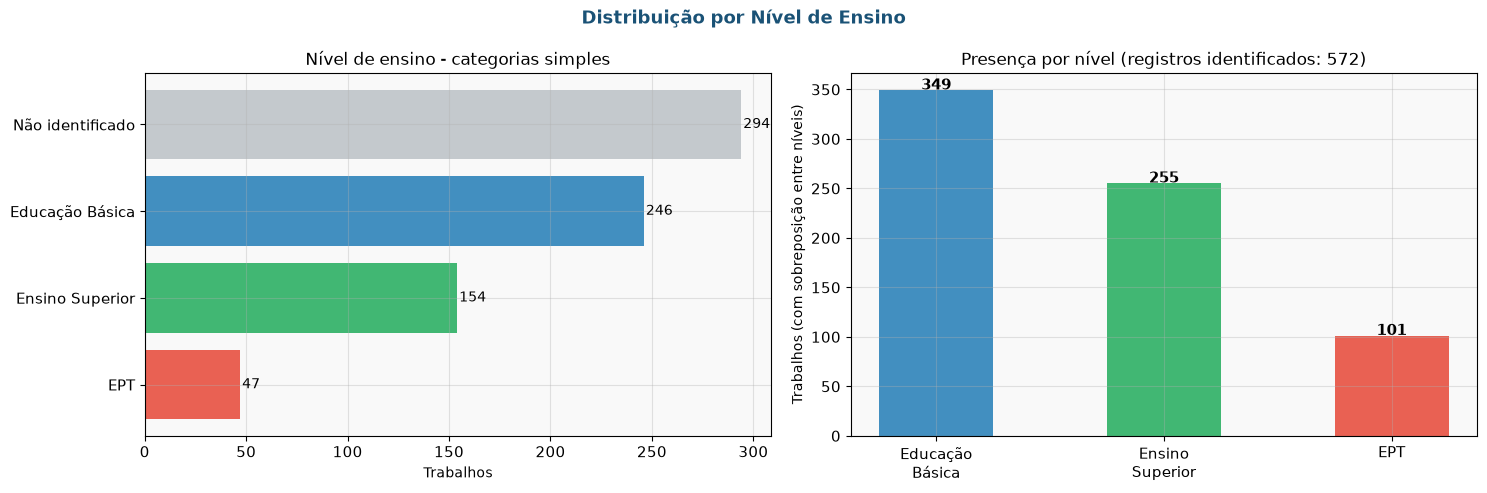

DISTRIBUIÇÃO POR NÍVEL DE ENSINO
  Total corpus:                          866
  Registros com nível identificado:      572 (66%)
  Não identificado:                      294 (34%)

  Nos 572 registros identificados:
    Educação Básica:  349 (61%)
    Ensino Superior:  255 (45%)
    EPT:              101 (18%)

  INTERPRETAÇÃO PARA O ESTADO DA ARTE:
  A EPT representa 18% dos trabalhos identificados por nível,
  confirmando que o corpus é dominado por estudos da Educação Básica
  e do Ensino Superior. Os 101 trabalhos com indicador EPT no corpus
  total são distintos dos 46
  classificados no Eixo 5: a diferença evidencia trabalhos que
  mencionam EPT marginalmente sem ter a EPT como foco central.

  TODAS AS CATEGORIAS (nivel_ensino, total=866):
     294 (  34%)  Não identificado
     246 (  28%)  Educação Básica
     154 (  18%)  Ensino Superior
      71 (   8%)  Ensino Superior | Educação Básica
      47 (   5%)  EPT
      24 (   3%)  EPT | Educação Básica
      22 (   3%)  EPT | En

In [6]:
# Distribuição por nível de ensino - corpus filtrado
TIPOS_INC = {
    'Dissertação (Mestrado)','Produto Educacional / Dissertação',
    'masterThesis','doctoralThesis','Dissertação','Tese'
}
mask_tipo    = df_raw['Tipo de Material'].isin(TIPOS_INC)
mask_periodo = (df_raw['Ano'] >= 2020) & (df_raw['Ano'] <= 2026)
mask_eixo    = df_raw['Eixo'].notna() & (df_raw['Eixo'].str.strip() != '')
df_corpus    = df_raw[mask_tipo & mask_periodo & mask_eixo].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribuição por Nível de Ensino', fontsize=13, fontweight='bold', color=ACCENT)

# 1. Distribuição geral
nivel_c = df_corpus['nivel_ensino'].value_counts()
cores_nivel = {
    'Educação Básica':'#2980b9',
    'Ensino Superior':'#27ae60',
    'EPT':'#e74c3c',
    'Não identificado':'#bdc3c7',
}

# Categorias simples (um único nível)
simples = {k: v for k, v in nivel_c.items() if '|' not in str(k)}
# Múltiplos níveis
multiplos = {k: v for k, v in nivel_c.items() if '|' in str(k)}

labels_s = list(simples.keys())
vals_s   = list(simples.values())
cores_s  = [cores_nivel.get(l, '#95a5a6') for l in labels_s]
axes[0].barh([str(l)[:35] for l in labels_s[::-1]], vals_s[::-1],
             color=cores_s[::-1], alpha=0.88)
axes[0].set_title('Nível de ensino - categorias simples')
axes[0].set_xlabel('Trabalhos')
for i, v in enumerate(vals_s[::-1]):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=10)

# 2. EPT vs outros - excluindo "Não identificado"
identificados = df_corpus[df_corpus['nivel_ensino'] != 'Não identificado']
n_id = len(identificados)

# Contar presença de cada nível (inclusive nos múltiplos)
n_ept  = identificados['nivel_ensino'].str.contains('EPT', na=False).sum()
n_sup  = identificados['nivel_ensino'].str.contains('Ensino Superior', na=False).sum()
n_bas  = identificados['nivel_ensino'].str.contains('Educação Básica', na=False).sum()

cats  = ['Educação\nBásica', 'Ensino\nSuperior', 'EPT']
vals  = [n_bas, n_sup, n_ept]
cores = ['#2980b9','#27ae60','#e74c3c']
bars  = axes[1].bar(cats, vals, color=cores, alpha=0.88, width=0.5)
axes[1].set_title(f'Presença por nível (registros identificados: {n_id})')
axes[1].set_ylabel('Trabalhos (com sobreposição entre níveis)')
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+1, str(v),
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('data/fig_nivel_ensino.png', dpi=150, bbox_inches='tight')
plt.show()

print("DISTRIBUIÇÃO POR NÍVEL DE ENSINO")
print("=" * 55)
print(f"  Total corpus:                          {len(df_corpus)}")
print(f"  Registros com nível identificado:      {n_id} ({n_id/len(df_corpus)*100:.0f}%)")
print(f"  Não identificado:                      {len(df_corpus)-n_id} ({(len(df_corpus)-n_id)/len(df_corpus)*100:.0f}%)")
print()
print(f"  Nos {n_id} registros identificados:")
print(f"    Educação Básica:  {n_bas} ({n_bas/n_id*100:.0f}%)")
print(f"    Ensino Superior:  {n_sup} ({n_sup/n_id*100:.0f}%)")
print(f"    EPT:              {n_ept} ({n_ept/n_id*100:.0f}%)")
print()
print("  INTERPRETAÇÃO PARA O ESTADO DA ARTE:")
print(f"  A EPT representa {n_ept/n_id*100:.0f}% dos trabalhos identificados por nível,")
print(f"  confirmando que o corpus é dominado por estudos da Educação Básica")
print(f"  e do Ensino Superior. Os {n_ept} trabalhos com indicador EPT no corpus")
print(f"  total são distintos dos {df_corpus['Eixo'].str.contains('Eixo 5',na=False).sum()}")
print(f"  classificados no Eixo 5: a diferença evidencia trabalhos que")
print(f"  mencionam EPT marginalmente sem ter a EPT como foco central.")


# Tabela completa nivel_ensino
print()
print("  TODAS AS CATEGORIAS (nivel_ensino, total={}):" .format(len(df_corpus)))
for v, c in df_corpus['nivel_ensino'].value_counts().items():
    print(f"    {c:>4} ({c/len(df_corpus)*100:4.0f}%)  {v}")
print()
print("  NIVEL DE ENSINO POR EIXO:")
print(f"  {'Nivel':<30}", end='')
for e in EIXOS:
    print(f"  {e}", end='')
print()
for cat in ['EPT','Ensino Superior','Educação Básica','Não identificado']:
    print(f"  {cat:<30}", end='')
    for e in EIXOS:
        sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
        pat = r'^Não identificado$' if cat == 'Não identificado' else cat
        n = sub['nivel_ensino'].str.contains(pat, regex=True, na=False).sum()
        print(f"  {n:>7}", end='')
    print()


## 4. Análise por Eixo Temático

Cada eixo é analisado quanto à distribuição temporal, tipo de material, sujeitos predominantes, instituições com maior produção, palavras-chave mais recorrentes e contribuição para a compreensão do objeto de pesquisa.

> Os trabalhos classificados em múltiplos eixos são contabilizados em cada eixo pertinente.


In [7]:
import re
from collections import Counter

STOPWORDS = {
    'para','com','uma','que','dos','das','por','nas','nos','não','são','mais',
    'sobre','como','seus','suas','este','esta','esse','essa','entre','pelo',
    'pela','num','sem','ter','ser','foi','seu','sua','isto','isso','também',
    'ainda','quando','onde','qual','todos','cada','muito','sendo','tendo',
    'fazer','feito','neste','nesta','após','antes','desde','até','pois','mas',
    'porém','este','esta','esses','essas','eles','elas','nos','nas','esse',
    'essa','isso','aqui','ali','há','lhe','lhes','seu','seus','sua','suas',
}
NID = 'Não identificado'

def top_kw(subdf, n=10):
    kws = []
    for k in subdf['Palavras-chave'].dropna():
        for t in re.split(r'[,;|]+', str(k)):
            t = t.strip().lower().replace('.','')
            if len(t) > 3 and t not in STOPWORDS and not t.isdigit():
                kws.append(t)
    return Counter(kws).most_common(n)

def normaliza(serie, vazio=None):
    v = NID if vazio is None else vazio
    return serie.replace('', v).fillna(v).apply(
        lambda x: v if str(x).strip().lower() in ('nan','none','') else str(x).strip()
    )

def analise_eixo(eixo_key):
    titulo = EIXO_FULL[eixo_key]
    sub = df_corpus[df_corpus['Eixo'].str.contains(eixo_key, regex=False, na=False)].copy()
    n = len(sub)

    print("=" * 68)
    print(f"  {titulo}")
    print(f"  {n} trabalhos no corpus")
    print("=" * 68)

    cor = PAL[EIXOS.index(eixo_key)]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    fig.suptitle(titulo, fontsize=11, fontweight='bold', color=ACCENT, y=1.01)

    # Linha 1: bibliometrico

    sub_ano = sub[(sub['Ano'] >= 2020) & (sub['Ano'] <= 2025)]
    ano_c = sub_ano.groupby('Ano').size().reindex(range(2020, 2026), fill_value=0)
    axes[0,0].bar(ano_c.index, ano_c.values, color=cor, alpha=0.85)
    axes[0,0].set_title('Publicações por Ano (2020-2025)')
    axes[0,0].set_ylabel('Trabalhos')
    axes[0,0].set_xticks(range(2020, 2026))
    for x, v in zip(ano_c.index, ano_c.values):
        if v > 0:
            axes[0,0].text(x, v + 0.3, str(v), ha='center', va='bottom', fontsize=9)

    tipo_c = normaliza(sub['Tipo'], 'Outro').value_counts().head(4)
    axes[0,1].barh(tipo_c.index[::-1], tipo_c.values[::-1], color=cor, alpha=0.85)
    axes[0,1].set_title('Tipo de Material')
    axes[0,1].set_xlabel('Trabalhos')
    for i, v in enumerate(tipo_c.values[::-1]):
        axes[0,1].text(v + 0.3, i, str(v), va='center', fontsize=10)

    kws = top_kw(sub, 10)
    if kws:
        kw_labels = [k[:35] for k, _ in kws]
        kw_vals   = [v for _, v in kws]
        axes[0,2].barh(kw_labels[::-1], kw_vals[::-1], color=cor, alpha=0.8)
        axes[0,2].set_title('Palavras-chave mais recorrentes')
        axes[0,2].set_xlabel('Frequência')
        axes[0,2].tick_params(axis='y', labelsize=8.5)

    # Linha 2: qualitativo — totais fecham em n

    te_c = normaliza(sub['tipo_estudo']).value_counts().head(8)
    cores_te = ['#bdc3c7' if v == NID else '#5d6d7e' for v in te_c.index]
    axes[1,0].barh([str(v)[:30] for v in te_c.index[::-1]], te_c.values[::-1],
                   color=cores_te[::-1], alpha=0.85)
    axes[1,0].set_title(f'Abordagem Metodológica (n={n})')
    axes[1,0].set_xlabel('Trabalhos')
    axes[1,0].tick_params(axis='y', labelsize=8.5)
    for i, v in enumerate(te_c.values[::-1]):
        axes[1,0].text(v + 0.2, i, str(v), va='center', fontsize=9)

    suj_c = normaliza(sub['Sujeitos da Pesquisa']).value_counts().head(7)
    cores_suj = ['#bdc3c7' if v == NID else '#7d6608' for v in suj_c.index]
    axes[1,1].barh([str(s)[:38] for s in suj_c.index[::-1]], suj_c.values[::-1],
                   color=cores_suj[::-1], alpha=0.75)
    axes[1,1].set_title(f'Sujeitos da Pesquisa (n={n})')
    axes[1,1].set_xlabel('Trabalhos')
    axes[1,1].tick_params(axis='y', labelsize=8.0)
    for i, v in enumerate(suj_c.values[::-1]):
        axes[1,1].text(v + 0.2, i, str(v), va='center', fontsize=9)

    niv_c = normaliza(sub['nivel_ensino']).value_counts().head(7)
    CORES_NIV = {'EPT':'#e74c3c','Ensino Superior':'#27ae60',
                 'Educação Básica':'#2980b9', NID:'#bdc3c7'}
    cores_niv = [CORES_NIV.get(v, '#95a5a6') for v in niv_c.index[::-1]]
    axes[1,2].barh([str(v)[:35] for v in niv_c.index[::-1]], niv_c.values[::-1],
                   color=cores_niv, alpha=0.85)
    axes[1,2].set_title(f'Nível de Ensino (n={n})')
    axes[1,2].set_xlabel('Trabalhos')
    axes[1,2].tick_params(axis='y', labelsize=8.5)
    for i, v in enumerate(niv_c.values[::-1]):
        axes[1,2].text(v + 0.2, i, str(v), va='center', fontsize=9)

    plt.tight_layout()
    fname = f"data/fig_{eixo_key.lower().replace(' ','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    # Sintese textual — totais sempre fecham em n
    print(f"\n  Tipo de material (total={n}):")
    for t, c in normaliza(sub['Tipo'],'Outro').value_counts().items():
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {t}")

    print(f"\n  Regiao (total={n}):")
    for r, c in normaliza(sub['Região do Brasil']).value_counts().head(6).items():
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {r}")

    print(f"\n  Abordagem metodológica (total={n}):")
    for t, c in normaliza(sub['tipo_estudo']).value_counts().head(7).items():
        nota = ' [sem indicador]' if t == NID else ' [inferido/manual]'
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {t}{nota}")

    print(f"\n  Sujeitos (total={n}):")
    for s, c in normaliza(sub['Sujeitos da Pesquisa']).value_counts().head(7).items():
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {s}")

    print(f"\n  Nível de ensino (total={n}):")
    for v, c in normaliza(sub['nivel_ensino']).value_counts().items():
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {v}")

    print(f"\n  Top 10 palavras-chave: {[k for k,_ in kws]}")
    print()

print("Função analise_eixo() carregada (totais fecham em n; Não identificado visível).")


Função analise_eixo() carregada (totais fecham em n; Não identificado visível).


### Eixo 1 - Educação de surdos + mediação

Mapeia a produção que articula **educação de surdos** com processos de **mediação pedagógica e linguística**. Constitui a base teórico-conceitual para compreender como a mediação opera nos contextos educativos investigados, subsidiando o uso das categorias vigotskianas (mediação, zona de desenvolvimento proximal, linguagem como condição do pensamento conceitual) e da Pedagogia Histórico-Crítica (Saviani, 2011) como referenciais centrais da pesquisa.

**Perfil metodológico predominante:** os estudos deste eixo recorrem majoritariamente a estudo de caso e pesquisa-ação - abordagens que privilegiam a compreensão situada dos processos mediadores em contextos educativos específicos. Essa tendência metodológica confirma que a mediação é investigada predominantemente em sua dimensão prática e relacional, e não como fenômeno abstrato.

**Sujeitos:** as pesquisas deste eixo incluem com frequência intérpretes de Libras e pessoas surdas/comunidade acadêmica como participantes centrais, revelando que a produção já reconhece a mediação como processo relacional - mas ainda tende a tratar professor e intérprete separadamente, sem focalizar a díade como unidade de análise.

**Contribuição para a pesquisa:** fornece o embasamento conceitual da mediação pedagógica e linguística como processo intencional de organização do acesso ao saber sistematizado - perspectiva que orienta a compreensão das práticas colaborativas entre professor e intérprete. A ausência de estudos que articulem mediação pedagógica *e* linguística de forma integrada, dentro de um mesmo campo empírico, é a lacuna específica que este eixo revela.

**Lacuna identificada:** a literatura tende a tratar mediação pedagógica (Saviani; Vigotski) e mediação linguística (tradução/interpretação em Libras) como fenômenos distintos, investigados em campos separados. A pesquisa propõe que, na EPT, esses dois processos são indissociáveis e exigem coplanejamento conjunto - argumento que não encontra suporte na literatura mapeada neste eixo.

  Eixo 1 - Educação de surdos + mediação
  146 trabalhos no corpus


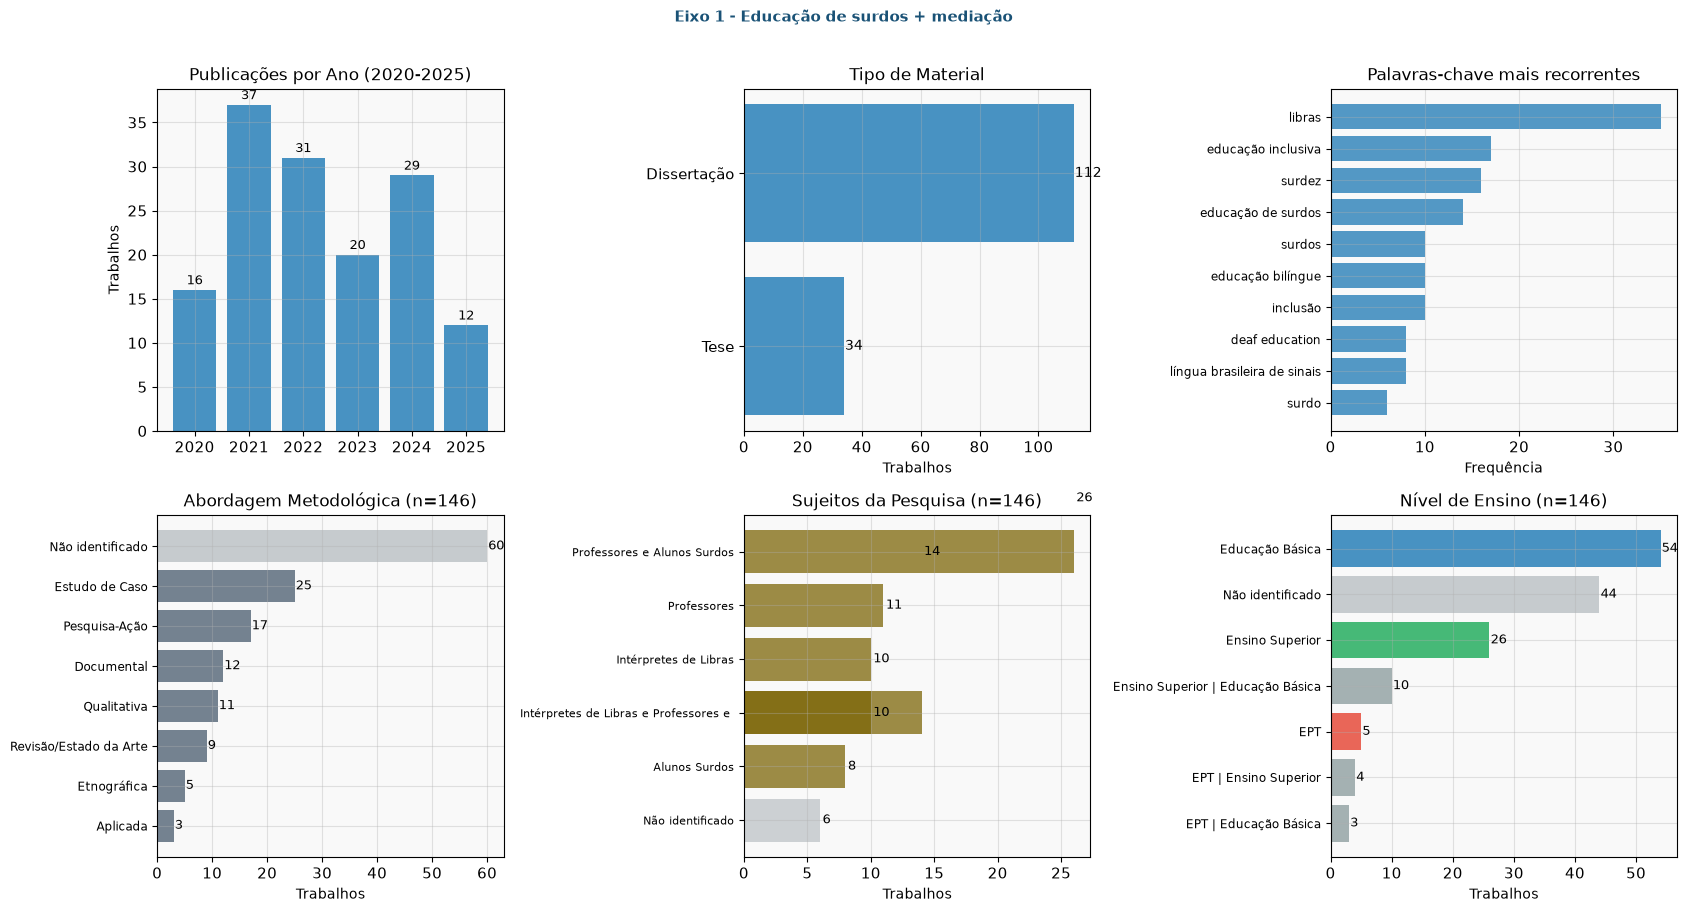


  Tipo de material (total=146):
     112 (  77%)  Dissertação
      34 (  23%)  Tese

  Regiao (total=146):
      47 (  32%)  Sudeste
      33 (  23%)  Não informada
      27 (  18%)  Sul
      26 (  18%)  Nordeste
      10 (   7%)  Norte
       3 (   2%)  Centro-Oeste

  Abordagem metodológica (total=146):
      60 (  41%)  Não identificado [sem indicador]
      25 (  17%)  Estudo de Caso [inferido/manual]
      17 (  12%)  Pesquisa-Ação [inferido/manual]
      12 (   8%)  Documental [inferido/manual]
      11 (   8%)  Qualitativa [inferido/manual]
       9 (   6%)  Revisão/Estado da Arte [inferido/manual]
       5 (   3%)  Etnográfica [inferido/manual]

  Sujeitos (total=146):
      26 (  18%)  Professores e Alunos Surdos
      14 (  10%)  Intérpretes de Libras e Professores e Alunos Surdos
      11 (   8%)  Professores
      10 (   7%)  Intérpretes de Libras
      10 (   7%)  Intérpretes de Libras e Professores e Alunos Surdos e Ouvintes
       8 (   5%)  Alunos Surdos
       6 (  

In [8]:
analise_eixo('Eixo 1')


### Eixo 2 - Educação de surdos + professor + intérprete *(Eixo Nuclear)*

> **Este é o eixo nuclear da pesquisa.** Mapeia diretamente a relação professor-intérprete em contextos bilíngues, as práticas colaborativas de mediação e os desafios da atuação conjunta - fenômeno central da investigação.

A produção deste eixo documenta como professores e intérpretes organizam (ou não) o trabalho pedagógico conjunto, quais estratégias de mediação são mobilizadas e quais condições institucionais favorecem ou dificultam a colaboração. Lacerda (2006) - a referência mais mobilizada nos trabalhos deste eixo - já identificava que a ausência de planejamento conjunto entre professor e intérprete compromete a qualidade da mediação; décadas depois, os estudos mapeados confirmam que o problema persiste, agora em novas configurações institucionais.

**Perfil metodológico predominante:** estudo de caso é a abordagem mais frequente (≈47% dos trabalhos classificados por tipo), seguido de revisão/estado da arte e pesquisa-ação. A prevalência do estudo de caso indica que o fenômeno ainda é investigado em recortes particulares e localizados - o que reforça a necessidade de pesquisas que articulem diagnóstico empírico à proposição de instrumentos replicáveis.

**Sujeitos:** a tríade professor-intérprete-aluno surdo aparece como configuração mais frequente nos estudos deste eixo, confirmando o reconhecimento de que a mediação é um fenômeno relacional. Contudo, a maioria das pesquisas mantém o foco na atuação *individual* do intérprete ou na *percepção dos alunos surdos* - poucos estudos elegem a *díade professor-intérprete* como unidade central de análise, que é exatamente o recorte desta investigação.

**Contribuição para a pesquisa:** os trabalhos de Lacerda (2006), Silva, Coimbra e Nascimento (2023) e demais autores mapeados neste eixo constituem a **base teórica e empírica mais próxima** dos objetivos específicos 1 e 2 da pesquisa. Eles documentam o fenômeno - a relação professor-intérprete -, mas raramente propõem instrumentos que a operacionalizem.

**Lacuna confirmada pelo eixo:** escassez de investigações sobre práticas colaborativas professor-intérprete especificamente no contexto da **Educação Profissional e Tecnológica** e dos **Institutos Federais**. A produção está concentrada na Educação Básica regular (Ensino Fundamental e Médio) e no Ensino Superior; o contexto técnico-profissional, com suas especificidades de densidade terminológica e cultura de formação, permanece sub-representado.

  Eixo 2 - Educação de surdos + professor/intérprete
  326 trabalhos no corpus


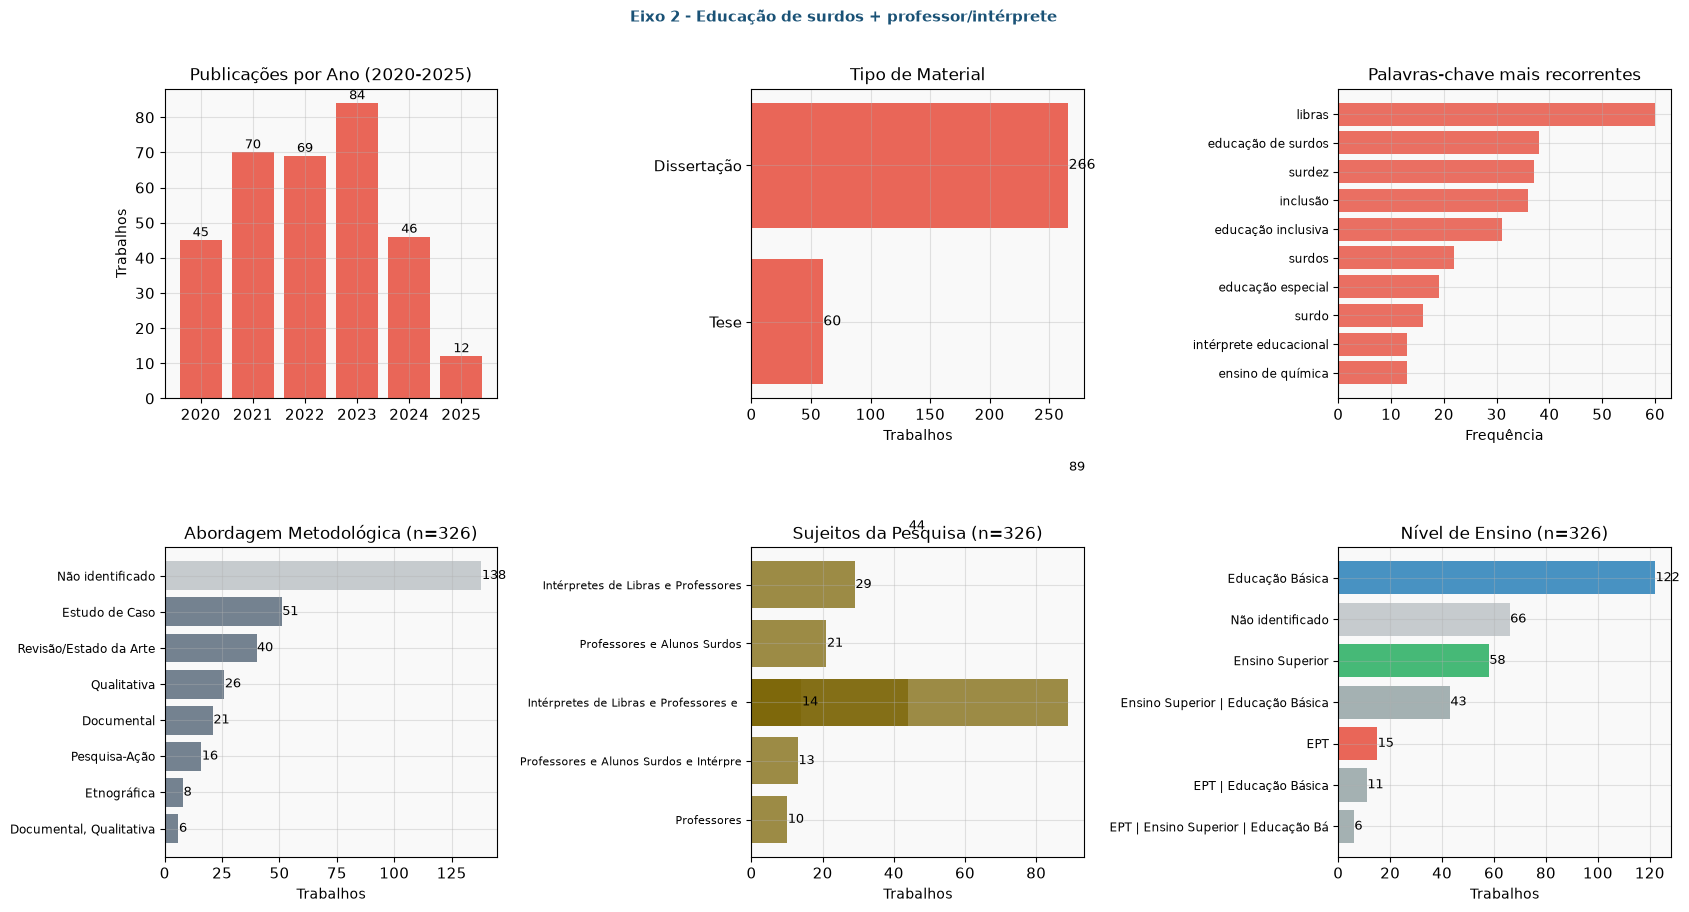


  Tipo de material (total=326):
     266 (  82%)  Dissertação
      60 (  18%)  Tese

  Regiao (total=326):
      99 (  30%)  Sudeste
      88 (  27%)  Não informada
      46 (  14%)  Nordeste
      36 (  11%)  Sul
      32 (  10%)  Norte
      25 (   8%)  Centro-Oeste

  Abordagem metodológica (total=326):
     138 (  42%)  Não identificado [sem indicador]
      51 (  16%)  Estudo de Caso [inferido/manual]
      40 (  12%)  Revisão/Estado da Arte [inferido/manual]
      26 (   8%)  Qualitativa [inferido/manual]
      21 (   6%)  Documental [inferido/manual]
      16 (   5%)  Pesquisa-Ação [inferido/manual]
       8 (   2%)  Etnográfica [inferido/manual]

  Sujeitos (total=326):
      89 (  27%)  Intérpretes de Libras e Professores e Alunos Surdos
      44 (  13%)  Intérpretes de Libras e Professores e Alunos Surdos e Ouvintes
      29 (   9%)  Intérpretes de Libras e Professores
      21 (   6%)  Professores e Alunos Surdos
      14 (   4%)  Intérpretes de Libras e Professores e Alun

In [9]:
analise_eixo('Eixo 2')


### Eixo 3 - Educação de surdos + colaboração

Mapeia a produção sobre **trabalho colaborativo**, **codocência** e **coplanejamento** em contextos de educação de surdos. Subsidia a compreensão das formas de organização do trabalho conjunto entre professores e intérpretes, explorando como a colaboração é operacionalizada nas práticas educativas e quais condições a favorecem ou inibem.

**Perfil metodológico predominante:** pesquisa-ação e estudo de caso dividem a liderança neste eixo - o que é metodologicamente coerente: a pesquisa-ação é especialmente adequada para investigar colaboração porque implica intervenção e coconstrução entre pesquisador e participantes, espelhando a própria lógica do objeto investigado. A presença relevante de pesquisa-ação aqui diferencia o Eixo 3 dos demais, sugerindo que a colaboração não é apenas descrita - ela é, em parte, *experimentada e induzida* no próprio processo de pesquisa.

**Sujeitos:** ao contrário dos demais eixos, este concentra investigações que incluem professores *e* intérpretes como sujeitos simultâneos, o que indica maior alinhamento com o recorte desta pesquisa. A tríade completa (professor-intérprete-aluno surdo) também aparece, mas a díade professor-intérprete é a unidade mais recorrente nos estudos sobre coplanejamento.

**Contribuição para a pesquisa:** fundamenta o construto de "práticas colaborativas" utilizado na investigação, distinguindo colaboração espontânea (baseada em boa vontade individual) de colaboração estrutural (ancorada em protocolos, ferramentas e tempos institucionais). Essa distinção é central para o argumento do Ambiente Bilíngue: o Produto Educacional não é mais um convite à colaboração - é um instrumento que a *estrutura*.

**Lacuna identificada:** carência de estudos sobre coplanejamento *sistemático* e *documentado* como prática recorrente (e não episódica). A literatura mapeada descreve colaborações situadas e momentâneas; faltam investigações que acompanhem a sustentabilidade de práticas colaborativas ao longo do ano letivo e em contextos de alta densidade terminológica.

  Eixo 3 - Educação de surdos + colaboração
  221 trabalhos no corpus


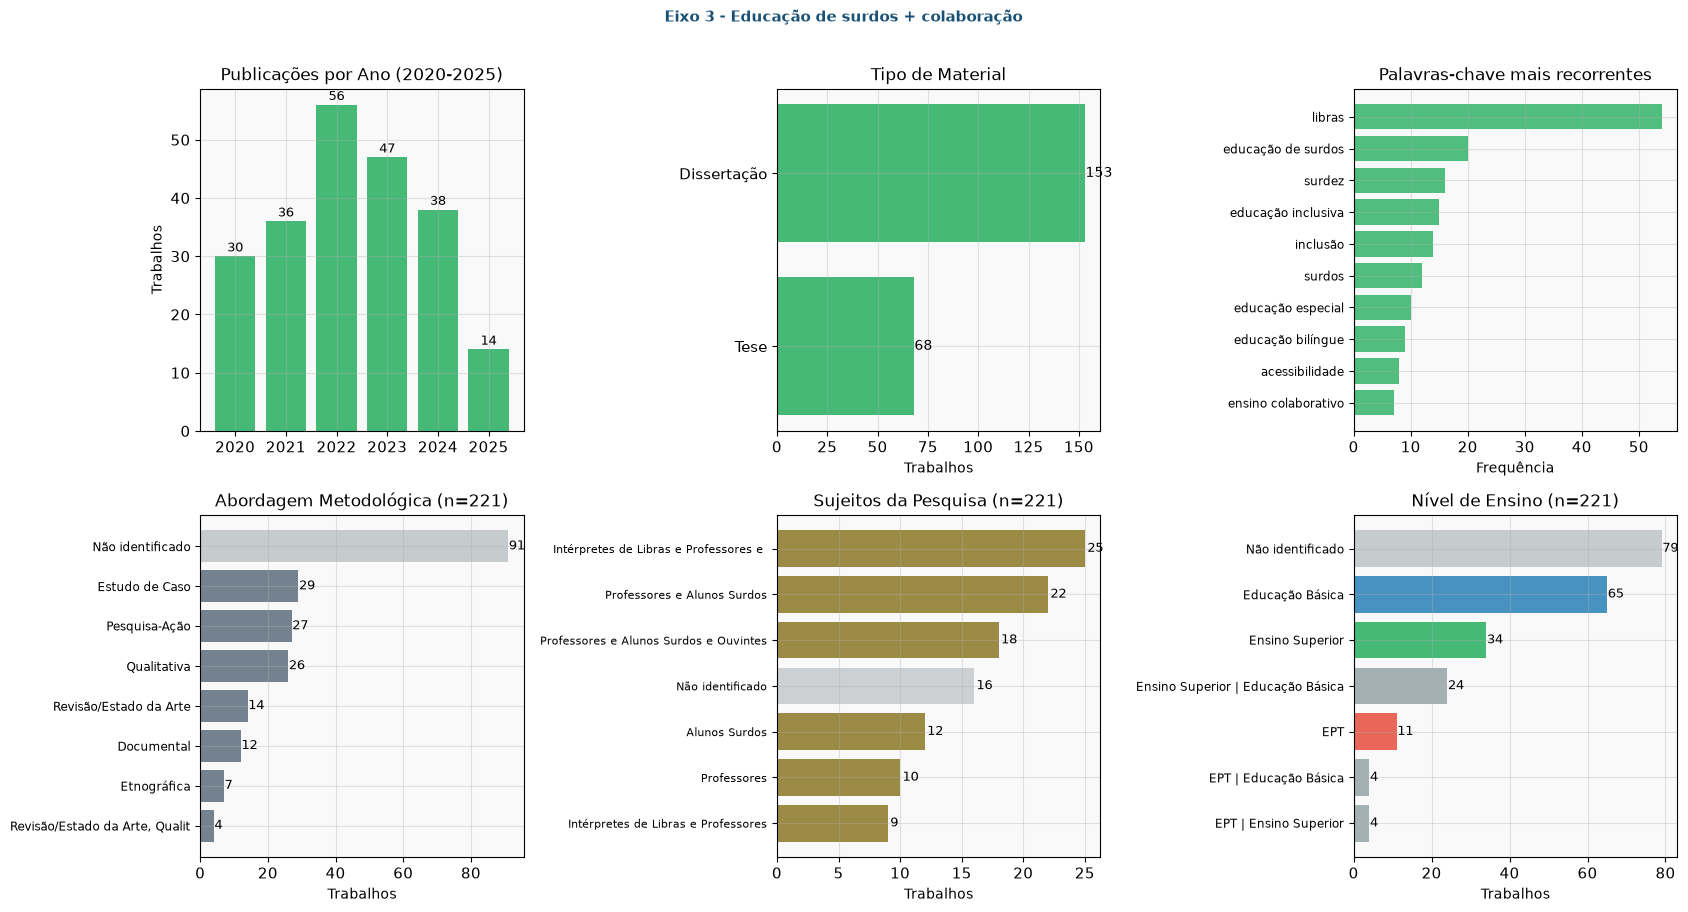


  Tipo de material (total=221):
     153 (  69%)  Dissertação
      68 (  31%)  Tese

  Regiao (total=221):
      63 (  29%)  Sudeste
      53 (  24%)  Não informada
      47 (  21%)  Nordeste
      24 (  11%)  Sul
      23 (  10%)  Centro-Oeste
      11 (   5%)  Norte

  Abordagem metodológica (total=221):
      91 (  41%)  Não identificado [sem indicador]
      29 (  13%)  Estudo de Caso [inferido/manual]
      27 (  12%)  Pesquisa-Ação [inferido/manual]
      26 (  12%)  Qualitativa [inferido/manual]
      14 (   6%)  Revisão/Estado da Arte [inferido/manual]
      12 (   5%)  Documental [inferido/manual]
       7 (   3%)  Etnográfica [inferido/manual]

  Sujeitos (total=221):
      25 (  11%)  Intérpretes de Libras e Professores e Alunos Surdos
      22 (  10%)  Professores e Alunos Surdos
      18 (   8%)  Professores e Alunos Surdos e Ouvintes
      16 (   7%)  Não identificado
      12 (   5%)  Alunos Surdos
      10 (   5%)  Professores
       9 (   4%)  Intérpretes de Libras e

In [10]:
analise_eixo('Eixo 3')


### Eixo 4 - Educação de surdos + tecnologias

Mapeia a produção sobre **tecnologias educacionais** para estudantes surdos: softwares, aplicativos, plataformas digitais, ambientes de aprendizagem, recursos de acessibilidade e hipermídias bilíngues. É o eixo com maior volume no corpus (n=444), o que indica maturidade da área - e, paradoxalmente, uma das lacunas mais nítidas para esta pesquisa.

**Perfil metodológico predominante:** estudo de caso lidera, mas pesquisa experimental e aplicada têm presença significativa (≈15–18% combinados), o que diferencia o Eixo 4 dos demais. Isso reflete a natureza do objeto: tecnologias são *desenvolvidas*, *testadas* e *avaliadas* - o que exige delineamentos que vão além do estudo descritivo. A pesquisa experimental aqui corresponde, em geral, à validação de protótipos ou artefatos com grupos de usuários.

**Sujeitos:** predominam pessoas surdas/comunidade acadêmica como usuárias das tecnologias desenvolvidas, com menor presença de professores e intérpretes como co-desenvolvedores ou avaliadores. Esse padrão é revelador: a tecnologia bilíngue é majoritariamente concebida *para* o aluno surdo, não *com* ou *entre* os mediadores. A participação do professor e do intérprete no processo de criação tecnológica é marginal na literatura levantada.

**Tecnologia empregada:** os trabalhos classificados com presença de artefato tecnológico (software/plataforma digital) correspondem a uma parcela relevante do eixo; a maioria, porém, foca em artefatos voltados ao usuário final (aluno surdo), não em ambientes de autoria compartilhada para mediadores.

**Contribuição para a pesquisa:** constitui a base empírica para o desenvolvimento do Produto Educacional (Ambiente Bilíngue de Mediação Conceitual), permitindo identificar soluções existentes, limitações das abordagens atuais e requisitos relevantes. A análise comparativa dos artefatos mapeados informa diretamente as decisões de design do PE.

**Lacuna confirmada:** a maioria das soluções tecnológicas está concentrada em **tradução automática** (e.g., VLibras), **glossários estáticos de Libras** e **recursos de acessibilidade individuais** para o aluno surdo. Há escassez marcante de **ambientes digitais colaborativos orientados à mediação conceitual** *entre* professores e intérpretes - nos quais ambos atuam como co-autores do processo pedagógico, registram combinados terminológicos e documentam o coplanejamento. Essa lacuna específica fundamenta e orienta a proposição do Ambiente Bilíngue como PE.

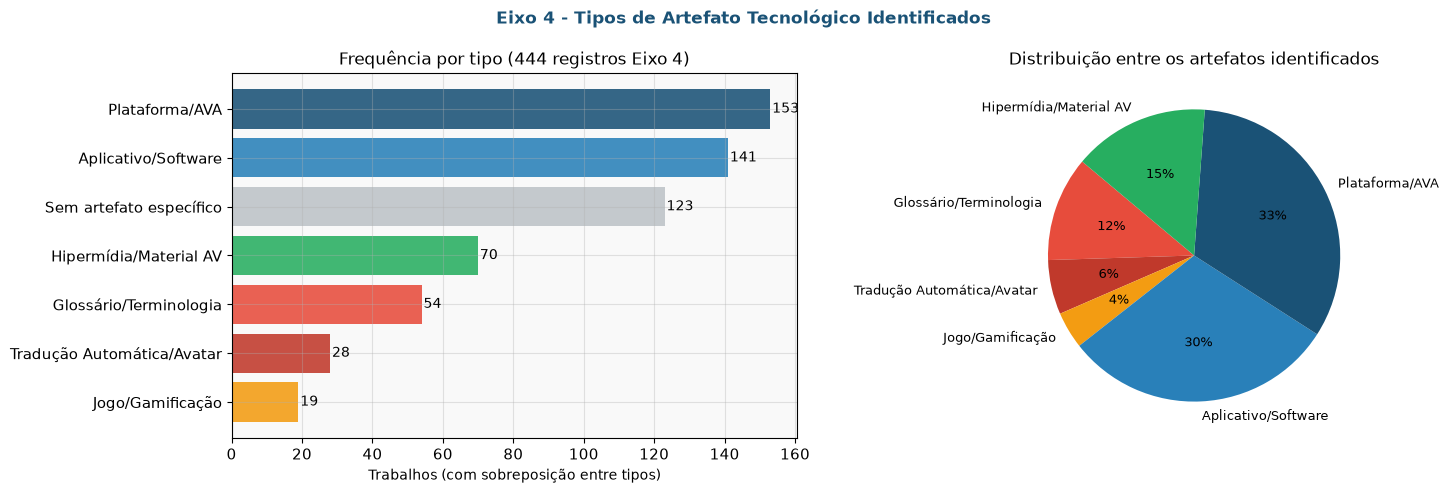

ANÁLISE DE ARTEFATOS - EIXO 4
  Glossário/Terminologia                 54 (12%)
  Tradução Automática/Avatar             28 (6%)
  Jogo/Gamificação                       19 (4%)
  Aplicativo/Software                   141 (32%)
  Plataforma/AVA                        153 (34%)
  Hipermídia/Material AV                 70 (16%)
  Sem artefato específico               123 (28%)

  Glossários + Tradução Automática (total): 78 (18%)

  INTERPRETAÇÃO:
  Glossários e tradução automática juntos representam
  18% dos trabalhos com artefato identificado no Eixo 4.
  Ambientes de MEDIAÇÃO CONCEITUAL COLABORATIVA (entre professor
  e intérprete como co-autores) estão ausentes do corpus -
  lacuna que fundamenta diretamente o Produto Educacional.

  TIPO DE ARTEFATO - TABELA COMPLETA (Eixo 4, n=444):
      54 (  12%)  Glossário/Terminologia
      28 (   6%)  Tradução Automática/Avatar
      19 (   4%)  Jogo/Gamificação
     141 (  32%)  Aplicativo/Software
     153 (  34%)  Plataforma/AVA
      70 

In [11]:
# Análise detalhada de tipo de artefato - Eixo 4
e4 = df_corpus[df_corpus['Eixo'].str.contains('Eixo 4', regex=False, na=False)].copy()

# Contar cada categoria (registros podem ter múltiplas)
CATS_ARTE = [
    'Glossário/Terminologia',
    'Tradução Automática/Avatar',
    'Jogo/Gamificação',
    'Aplicativo/Software',
    'Plataforma/AVA',
    'Hipermídia/Material AV',
    'Sem artefato específico',
]

counts_arte = {}
for cat in CATS_ARTE:
    counts_arte[cat] = e4['tipo_artefato'].str.contains(cat, regex=False, na=False).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Eixo 4 - Tipos de Artefato Tecnológico Identificados',
             fontsize=12, fontweight='bold', color=ACCENT)

# Barra horizontal por categoria
cats_sorted  = sorted(counts_arte.keys(), key=lambda k: counts_arte[k])
vals_sorted  = [counts_arte[k] for k in cats_sorted]
CORES_ARTE = {
    'Glossário/Terminologia':      '#e74c3c',
    'Tradução Automática/Avatar':  '#c0392b',
    'Jogo/Gamificação':            '#f39c12',
    'Aplicativo/Software':         '#2980b9',
    'Plataforma/AVA':              '#1a5276',
    'Hipermídia/Material AV':      '#27ae60',
    'Sem artefato específico':     '#bdc3c7',
}
axes[0].barh(cats_sorted, vals_sorted,
             color=[CORES_ARTE.get(c,'#95a5a6') for c in cats_sorted], alpha=0.88)
axes[0].set_title(f'Frequência por tipo ({len(e4)} registros Eixo 4)')
axes[0].set_xlabel('Trabalhos (com sobreposição entre tipos)')
for i, v in enumerate(vals_sorted):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=10)

# Pizza: proporção geral (excluindo "Sem artefato")
artefato_presentes = {k: v for k, v in counts_arte.items()
                      if k != 'Sem artefato específico' and v > 0}
axes[1].pie(artefato_presentes.values(),
            labels=artefato_presentes.keys(),
            colors=[CORES_ARTE.get(k,'#95a5a6') for k in artefato_presentes],
            autopct='%1.0f%%', startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Distribuição entre os artefatos identificados')

plt.tight_layout()
plt.savefig('data/fig_tipo_artefato_e4.png', dpi=150, bbox_inches='tight')
plt.show()

n_gloss_trad = e4['tipo_artefato'].str.contains(
    'Glossário|Tradução Automática', regex=True, na=False).sum()
n_colab = e4['tipo_artefato'].str.contains(
    'Sem artefato', regex=False, na=False).sum()
n_total = len(e4)

print("ANÁLISE DE ARTEFATOS - EIXO 4")
print("=" * 55)
for cat in CATS_ARTE:
    n = counts_arte[cat]
    print(f"  {cat:<36} {n:>4} ({n/n_total*100:.0f}%)")
print()
print(f"  Glossários + Tradução Automática (total): {n_gloss_trad} ({n_gloss_trad/n_total*100:.0f}%)")
print()
print("  INTERPRETAÇÃO:")
print("  Glossários e tradução automática juntos representam")
print(f"  {n_gloss_trad/n_total*100:.0f}% dos trabalhos com artefato identificado no Eixo 4.")
print("  Ambientes de MEDIAÇÃO CONCEITUAL COLABORATIVA (entre professor")
print("  e intérprete como co-autores) estão ausentes do corpus -")
print("  lacuna que fundamenta diretamente o Produto Educacional.")


# Tabela completa tipo_artefato
print()
print("  TIPO DE ARTEFATO - TABELA COMPLETA (Eixo 4, n={}):" .format(len(e4)))
for cat in CATS_ARTE:
    n = counts_arte[cat]
    pct = n/len(e4)*100
    print(f"    {n:>4} ({pct:4.0f}%)  {cat}")
print()
print("  COMBINACOES MAIS FREQUENTES:")
for v, c in e4['tipo_artefato'].value_counts().head(12).items():
    print(f"    {c:>4} ({c/len(e4)*100:4.0f}%)  {str(v)[:65]}")
print()
total_com_arte = len(e4) - counts_arte.get('Sem artefato específico', 0)
print(f"  Com artefato identificado: {total_com_arte} ({total_com_arte/len(e4)*100:.0f}%)")
print(f"  Sem artefato específico:   {counts_arte.get('Sem artefato específico',0)}")


  Eixo 4 - Educação de surdos + tecnologias
  444 trabalhos no corpus


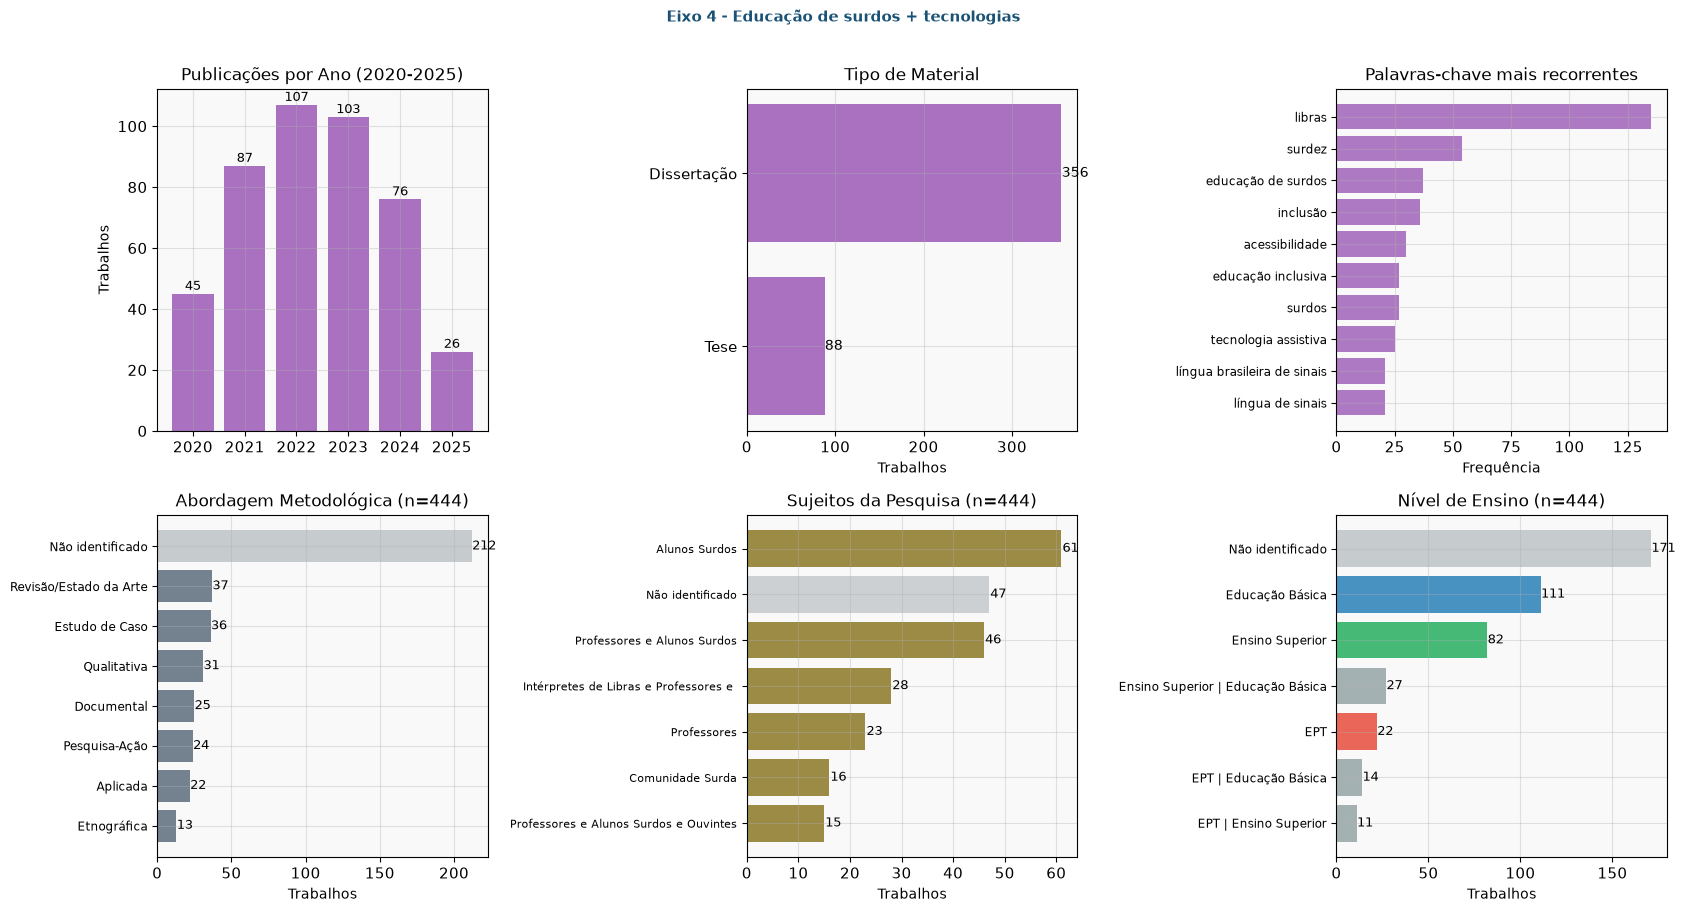


  Tipo de material (total=444):
     356 (  80%)  Dissertação
      88 (  20%)  Tese

  Regiao (total=444):
     122 (  27%)  Não informada
     109 (  25%)  Sudeste
      83 (  19%)  Nordeste
      60 (  14%)  Sul
      40 (   9%)  Centro-Oeste
      30 (   7%)  Norte

  Abordagem metodológica (total=444):
     212 (  48%)  Não identificado [sem indicador]
      37 (   8%)  Revisão/Estado da Arte [inferido/manual]
      36 (   8%)  Estudo de Caso [inferido/manual]
      31 (   7%)  Qualitativa [inferido/manual]
      25 (   6%)  Documental [inferido/manual]
      24 (   5%)  Pesquisa-Ação [inferido/manual]
      22 (   5%)  Aplicada [inferido/manual]

  Sujeitos (total=444):
      61 (  14%)  Alunos Surdos
      47 (  11%)  Não identificado
      46 (  10%)  Professores e Alunos Surdos
      28 (   6%)  Intérpretes de Libras e Professores e Alunos Surdos
      23 (   5%)  Professores
      16 (   4%)  Comunidade Surda
      15 (   3%)  Professores e Alunos Surdos e Ouvintes

  Nível 

In [12]:
analise_eixo('Eixo 4')


### Eixo 5 - Educação Profissional e Tecnológica (EPT)

Embora o menor em volume (n=46), **este eixo é estrategicamente decisivo**: delimita o estado da arte especificamente no contexto da **EPT e dos Institutos Federais** - campo onde a pesquisa se desenvolve. A baixa produção identificada, em contraste com o volume dos demais eixos, confirma empiricamente a **lacuna científica** que justifica e orienta esta investigação.

**Perfil metodológico predominante:** estudo de caso e pesquisa-ação aparecem em proporção equilibrada - o que indica que, nos poucos estudos que investigam surdos na EPT, os pesquisadores tendem a combinar diagnóstico e intervenção. Isso é coerente com o caráter do ProfEPT (mestrado profissional): a maioria desses trabalhos provavelmente provém de programas de pós-graduação profissional, que exigem articulação entre pesquisa e produto.

**Sujeitos:** a base de dados é pequena, mas evidencia que os estudos da EPT tendem a incluir a tríade ou subconjuntos dela. A presença de alunos surdos como sujeitos indica foco na experiência discente - enquanto a relação professor-intérprete, central para esta pesquisa, ainda aparece pouco como objeto específico neste contexto.

**Especificidade do contexto EPT:** a ausência de parceria efetiva entre professores e intérpretes nos IFs - identificada por Silva, Coimbra e Nascimento (2023) como um dos principais desafios - é confirmada pelo próprio silêncio da literatura: se o problema existisse como objeto de investigação sistemática, o Eixo 5 seria mais volumoso. A incipiente produção sobre TILS + EPT é, ela mesma, um dado analítico.

**Por que a EPT exige investigação própria:** os conteúdos técnico-profissionais (Edificações, Eletrotécnica, Mecânica, Informática etc.) impõem desafios de mediação conceitual qualitativamente distintos dos da Educação Básica geral. A densidade terminológica especializada, muitas vezes sem equivalentes consolidados em Libras, coloca professor e intérprete diante de um problema de *construção conjunta do saber técnico* - não apenas de tradução. Esse fenômeno específico não é abordado pelos trabalhos dos Eixos 1–4, que se desenvolvem predominantemente em contextos de Educação Básica ou Ensino Superior de formação geral.

**Referência de destaque no eixo:** a dissertação de Oliveira (2024), do próprio ProfEPT/IFG, é o trabalho mais próximo desta investigação no Eixo 5. Ao defender a "prática tríade" (professor-intérprete-aluno) e propor um E-book de conscientização, Oliveira ilumina o problema e também delimita o ponto de partida desta pesquisa: o Ambiente Bilíngue avança do diagnóstico atitudinal para a instrumentalização operacional do coplanejamento (ver Seção 1.1 da dissertação).

**Lacuna confirmada:** o subcampo "TILS + EPT" é emergente e as poucas referências disponíveis não são suficientes para orientar práticas sistematizadas nem subsidiar políticas institucionais nos Institutos Federais. A pesquisa se justifica por ocupar esse espaço com rigor empírico e proposição instrumental.

  Eixo 5 - Educação Profissional e Tecnológica
  46 trabalhos no corpus


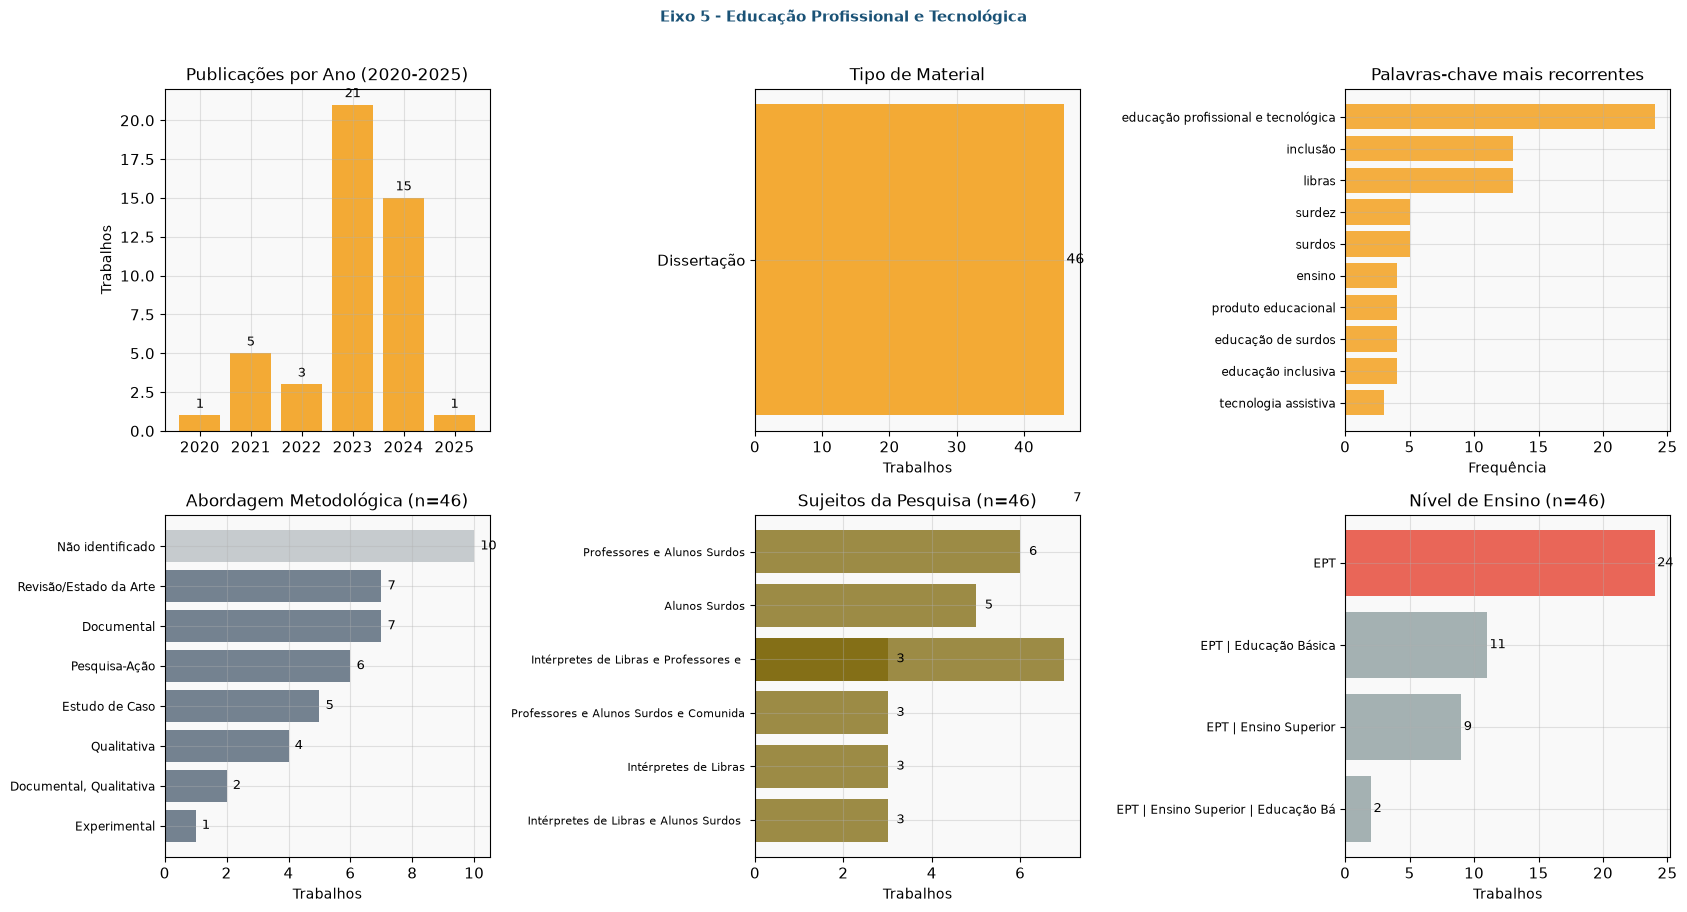


  Tipo de material (total=46):
      46 ( 100%)  Dissertação

  Regiao (total=46):
      34 (  74%)  Sudeste
       5 (  11%)  Nordeste
       3 (   7%)  Não informada
       2 (   4%)  Norte
       1 (   2%)  Centro-Oeste
       1 (   2%)  Sul

  Abordagem metodológica (total=46):
      10 (  22%)  Não identificado [sem indicador]
       7 (  15%)  Revisão/Estado da Arte [inferido/manual]
       7 (  15%)  Documental [inferido/manual]
       6 (  13%)  Pesquisa-Ação [inferido/manual]
       5 (  11%)  Estudo de Caso [inferido/manual]
       4 (   9%)  Qualitativa [inferido/manual]
       2 (   4%)  Documental, Qualitativa [inferido/manual]

  Sujeitos (total=46):
       7 (  15%)  Intérpretes de Libras e Professores e Alunos Surdos
       6 (  13%)  Professores e Alunos Surdos
       5 (  11%)  Alunos Surdos
       3 (   7%)  Intérpretes de Libras e Professores e Alunos Surdos e Ouvintes
       3 (   7%)  Professores e Alunos Surdos e Comunidade Surda
       3 (   7%)  Intérpretes de

In [13]:
analise_eixo('Eixo 5')


## 5. Visão Cruzada dos Eixos

Mapa de calor da cobertura temporal e análise dos trabalhos classificados em múltiplos eixos, que representam maior integração temática com o objeto da pesquisa.


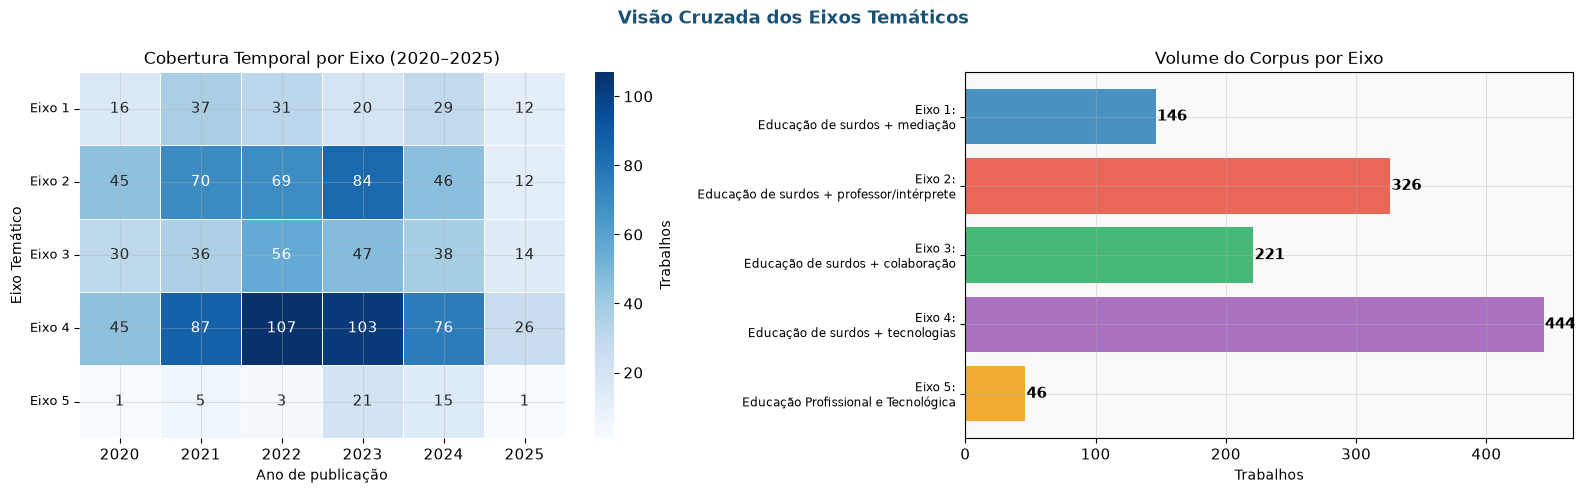


TRABALHOS EM MÚLTIPLOS EIXOS (integração temática mais ampla)
Total: 262 trabalhos em ≥ 2 eixos | 50 em ≥ 3 eixos

[4 eixos] (2022) Práticas inclusivas: análise da formação e atuação do professor intérprete de Libras
  OLIVEIRA NETO, Artur Maciel
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2022) Análise das percepções de licenciandos em Biologia, Física e Química da UFV sobre a Educaç
  Bozzi, Raquel Alves
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2022) Práticas inclusivas: análise da formação e atuação do professor intérprete de Libras
  Oliveira Neto, Artur Maciel
  Eixos: Eixo 1 — Educação de surdos + mediação | Eixo 2 — Educação de surdos + professor + intérprete | Eixo 3 — Educação de sur

[4 eixos] (2024) Inclusão de alunos surdos na educação profissional e tecnológica: a comunicação 

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Visão Cruzada dos Eixos Temáticos', fontsize=13, fontweight='bold', color=ACCENT)

# Mapa de calor Eixo × Ano
df_foco = df_corpus[(df_corpus['Ano'] >= 2020) & (df_corpus['Ano'] <= 2025)].copy()
heat_data = {}
for e in EIXOS:
    heat_data[e] = {}
    for ano in range(2020, 2026):
        mask = (df_foco['Eixo'].str.contains(e, regex=False, na=False)) & (df_foco['Ano'] == ano)
        heat_data[e][ano] = mask.sum()

heat_df = pd.DataFrame(heat_data).T
sns.heatmap(heat_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Trabalhos'})
axes[0].set_title('Cobertura Temporal por Eixo (2020–2025)')
axes[0].set_ylabel('Eixo Temático')
axes[0].set_xlabel('Ano de publicação')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)

# Volume por eixo (barras horizontais)
ns_eixo = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
nomes = [EIXO_FULL[e].replace(' - ', ':\n') for e in EIXOS]
axes[1].barh(nomes[::-1], ns_eixo[::-1], color=PAL[:5][::-1], alpha=0.85)
axes[1].set_title('Volume do Corpus por Eixo')
axes[1].set_xlabel('Trabalhos')
for i, v in enumerate(ns_eixo[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold', fontsize=11)
axes[1].tick_params(axis='y', labelsize=8.5)

plt.tight_layout()
plt.savefig('data/fig_visao_cruzada.png', dpi=150, bbox_inches='tight')
plt.show()

# Trabalhos em múltiplos eixos
print("\nTRABALHOS EM MÚLTIPLOS EIXOS (integração temática mais ampla)")
print("=" * 65)
multi_df = df_corpus[df_corpus['Eixo'].str.contains('|', regex=False, na=False)].copy()
multi_df['n_eixos'] = multi_df['Eixo'].str.count('\\|') + 1
print(f"Total: {len(multi_df)} trabalhos em ≥ 2 eixos | "
      f"{len(multi_df[multi_df['n_eixos']>=3])} em ≥ 3 eixos\n")

top_multi = multi_df.nlargest(10, 'n_eixos')[['Título','Autor(es)','Ano','n_eixos','Eixo']]
for _, row in top_multi.iterrows():
    ano = int(row['Ano']) if pd.notna(row['Ano']) else '?'
    print(f"[{int(row['n_eixos'])} eixos] ({ano}) {str(row['Título'])[:90]}")
    print(f"  {str(row['Autor(es)'])[:65]}")
    print(f"  Eixos: {str(row['Eixo'])[:120]}")
    print()


# Tabela textual completa — heatmap eixo x ano
print()
print("COBERTURA TEMPORAL POR EIXO (2020-2025)")
print("=" * 60)
header = f"{'Eixo':<12}" + "".join(f"  {a}" for a in range(2020, 2026)) + "  Total"
print(header)
print("-" * 60)
for e in EIXOS:
    row = f"{e:<12}"
    total_e = 0
    for ano in range(2020, 2026):
        mask = (df_foco['Eixo'].str.contains(e, regex=False, na=False)) & (df_foco['Ano'] == ano)
        n = mask.sum()
        total_e += n
        row += f"  {n:>4}"
    row += f"  {total_e:>5}"
    print(row)
print("-" * 60)
print(f"{'TOTAL':<12}" + "".join(
    f"  {(df_foco['Ano']==a).sum():>4}" for a in range(2020, 2026)
) + f"  {len(df_foco):>5}")
print()

print("TRABALHOS EM MULTIPLOS EIXOS:")
print(f"  Total em 2+ eixos:  {len(multi_df)}")
print(f"  Total em 3+ eixos:  {len(multi_df[multi_df['n_eixos']>=3])}")
print()
print("  Top 10 (maior integracao tematica):")
for _, row in top_multi.iterrows():
    ano = int(row['Ano']) if pd.notna(row['Ano']) else '?'
    print(f"  [{int(row['n_eixos'])} eixos] ({ano}) {str(row['Título'])[:80]}")
    print(f"    Autor: {str(row['Autor(es)'])[:60]}")
    print(f"    Eixos: {str(row['Eixo'])[:100]}")


## 5.1 Perfil Qualitativo Comparativo dos Eixos

Além da distribuição bibliométrica, o corpus foi analisado quanto ao **perfil metodológico** (tipo de estudo), **sujeitos predominantes** e **presença de artefato tecnológico** - dimensões qualitativas que permitem compreender *como* a literatura investiga cada temática, e não apenas *quanto* produz.

Esta análise revela padrões interpretativamente relevantes:
- A **pesquisa-ação** predomina nos eixos de colaboração (Eixo 3) e EPT (Eixo 5), indicando que esses campos investigam a prática *intervindo* nela - o que é coerente com o perfil dos mestrados profissionais.
- O **estudo de caso** domina nos eixos de mediação (Eixo 1) e professor/intérprete (Eixo 2), refletindo investigações situadas em contextos específicos, geralmente sem proposta de instrumento replicável.
- A **pesquisa experimental/aplicada** aparece com mais força no Eixo 4 (tecnologias), onde a validação de artefatos exige delineamentos mais controlados.
- A **díade professor-intérprete** como unidade de análise exclusiva aparece raramente - a maioria dos estudos inclui o aluno surdo como sujeito central ou co-sujeito principal.

PERFIL METODOLÓGICO DO CORPUS POR EIXO TEMÁTICO
(campo 'tipo_estudo': preenchimento manual preservado; lacunas inferidas
 por palavras-chave em títulos e resumos — 33% de cobertura automática)
Tipo de Estudo                        Eixo 1      Eixo 2      Eixo 3      Eixo 4      Eixo 5
---------------------------------------------------------------------------
Estudo de Caso                            27          55          31          41           6
Qualitativa                               11          37          34          53           7
Revisão/Estado da Arte                    10          47          20          51          10
Documental                                15          31          17          42          10
Pesquisa-Ação                             18          17          29          28           6
Etnográfica                                7          10           8          13           0
Aplicada                                   3           2           1          25

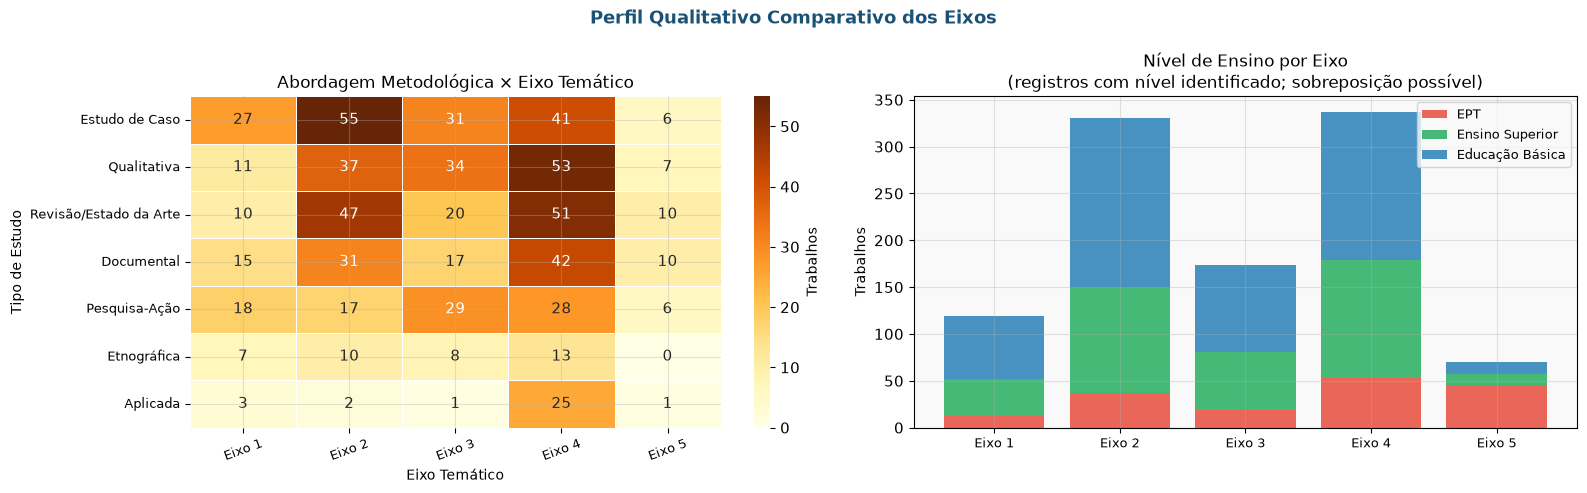

NÍVEL DE ENSINO POR EIXO (registros identificados por palavra-chave)
Nível                           Eixo 1      Eixo 2      Eixo 3      Eixo 4      Eixo 5
---------------------------------------------------------------------------
EPT                                 12          37          19          53          46
Ensino Superior                     40         112          62         126          11
Educação Básica                     67         182          93         158          13
Não identificado                    44          66          79         171           0
---------------------------------------------------------------------------
  Eixo 1: n=146  Eixo 2: n=326  Eixo 3: n=221  Eixo 4: n=444  Eixo 5: n=46

NOTA: Um mesmo trabalho pode ser classificado em múltiplos níveis de ensino.
'Não identificado' indica ausência de indicador explícito no título/resumo,
não necessariamente ausência de nível de ensino no trabalho.

SUJEITOS DA PESQUISA POR EIXO (top categorias, n tota

In [15]:
from collections import defaultdict
import re as _re
import numpy as np

# Tabela comparativa: tipo de estudo por eixo
# (combina preenchimento manual com inferencia automatica por palavra-chave)
print("PERFIL METODOLÓGICO DO CORPUS POR EIXO TEMÁTICO")
print("(campo 'tipo_estudo': preenchimento manual preservado; lacunas inferidas")
print(" por palavras-chave em títulos e resumos — 33% de cobertura automática)")
print("=" * 75)

te_matrix = {}
for e in EIXOS:
    sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    te_raw = sub['tipo_estudo'].replace('','').fillna('')
    te_raw = te_raw[(te_raw != '') & (te_raw != 'Não identificado')]
    contagens = defaultdict(int)
    for val in te_raw:
        for parte in str(val).split(','):
            parte = parte.strip()
            if parte:
                contagens[parte] += 1
    te_matrix[e] = contagens

header = f"{'Tipo de Estudo':<32}" + "".join(f"{e:>12}" for e in EIXOS)
print(header)
print("-" * 75)
todos_tipos = sorted(
    set(t for d in te_matrix.values() for t in d.keys()),
    key=lambda x: -sum(d.get(x, 0) for d in te_matrix.values())
)
for tipo in todos_tipos:
    row = f"{tipo:<32}" + "".join(f"{te_matrix[e].get(tipo,0):>12}" for e in EIXOS)
    print(row)
print("-" * 75)
totais = {e: sum(te_matrix[e].values()) for e in EIXOS}
n_eixo = {e: df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS}
print(f"{'Total classificados':<32}" + "".join(f"{totais[e]:>12}" for e in EIXOS))
print(f"{'(% do corpus do eixo)':<32}" + "".join(
    f"{'(%d%%)'%round(totais[e]/n_eixo[e]*100):>12}" for e in EIXOS))
print()

# Figura 1: Heatmap tipo_estudo x eixo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Perfil Qualitativo Comparativo dos Eixos', fontsize=13, fontweight='bold', color=ACCENT)

top_tipos = todos_tipos[:7]
heat = np.array([[te_matrix[e].get(t, 0) for e in EIXOS] for t in top_tipos])
sns.heatmap(heat, annot=True, fmt='d', cmap='YlOrBr', ax=axes[0],
            xticklabels=EIXOS, yticklabels=top_tipos,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Trabalhos'})
axes[0].set_title('Abordagem Metodológica × Eixo Temático')
axes[0].set_xlabel('Eixo Temático')
axes[0].set_ylabel('Tipo de Estudo')
axes[0].tick_params(axis='x', rotation=20, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Figura 2: Nível de ensino por eixo
nivel_cats = ['EPT','Ensino Superior','Educação Básica']
cores_n = {'EPT':'#e74c3c','Ensino Superior':'#27ae60','Educação Básica':'#2980b9'}
bottom = np.zeros(len(EIXOS))
x = np.arange(len(EIXOS))
for cat in nivel_cats:
    vals = []
    for e in EIXOS:
        sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
        n = sub['nivel_ensino'].str.contains(cat, regex=False, na=False).sum()
        vals.append(n)
    axes[1].bar(x, vals, bottom=bottom, label=cat, color=cores_n[cat], alpha=0.85)
    bottom += np.array(vals)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EIXOS, fontsize=9)
axes[1].set_title('Nível de Ensino por Eixo\n(registros com nível identificado; sobreposição possível)')
axes[1].set_ylabel('Trabalhos')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/fig_perfil_qualitativo.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela nivel_ensino por eixo
print("NÍVEL DE ENSINO POR EIXO (registros identificados por palavra-chave)")
print("=" * 75)
header2 = f"{'Nível':<26}" + "".join(f"{e:>12}" for e in EIXOS)
print(header2)
print("-" * 75)
for cat in nivel_cats + ['Não identificado']:
    row = f"{cat:<26}"
    for e in EIXOS:
        sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
        n = sub['nivel_ensino'].str.contains(cat if cat != 'Não identificado' else '^Não identificado$',
                                              regex=True, na=False).sum()
        row += f"{n:>12}"
    print(row)
print("-" * 75)
for e in EIXOS:
    sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    print(f"  {e}: n={len(sub)}", end='')
print()
print()
print("NOTA: Um mesmo trabalho pode ser classificado em múltiplos níveis de ensino.")
print("'Não identificado' indica ausência de indicador explícito no título/resumo,")
print("não necessariamente ausência de nível de ensino no trabalho.")


# Tabela completa sujeitos por eixo
print()
print("SUJEITOS DA PESQUISA POR EIXO (top categorias, n total do eixo)")
print("=" * 65)
for e in EIXOS:
    sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    n = len(sub)
    print(f"\n  {EIXO_FULL[e]} (n={n}):")
    suj = sub['Sujeitos da Pesquisa'].replace('','Não identificado').fillna('Não identificado')
    for v, c in suj.value_counts().head(6).items():
        print(f"    {c:>4} ({c/n*100:4.0f}%)  {str(v)[:65]}")


## 6. Lacunas Identificadas no Estado da Arte

A análise do corpus por eixo permite mapear as **lacunas científicas** que fundamentam e orientam esta pesquisa, entendidas como zonas de silêncio ou de investigação insuficiente na produção acadêmica levantada.


SÍNTESE DAS LACUNAS IDENTIFICADAS

Eixo 1 (mediação) (146 trabalhos):
  → Escassez de estudos que articulem mediação pedagógica E linguística de
    forma integrada no contexto bilíngue. A produção tende a tratar as duas
    dimensões de forma separada.

Eixo 2 (prof./intérp.) (326 trabalhos):
  → Poucos estudos investigam especificamente as PRÁTICAS COLABORATIVAS entre
    professor e intérprete na EPT/Institutos Federais. A maioria aborda a
    Educação Básica regular.

Eixo 3 (colaboração) (221 trabalhos):
  → Carência de estudos sobre coplanejamento sistemático e organização
    compartilhada de referências conceituais entre professor e intérprete como
    unidade de análise.

Eixo 4 (tecnologias) (444 trabalhos):
  → A produção está concentrada em tradução automática e glossários de Libras.
    Há escassez de ambientes digitais voltados à MEDIAÇÃO CONCEITUAL bilíngue
    colaborativa.

Eixo 5 (EPT) (46 trabalhos):
  → Volume muito reduzido de produção sobre surdos/TILS especificam

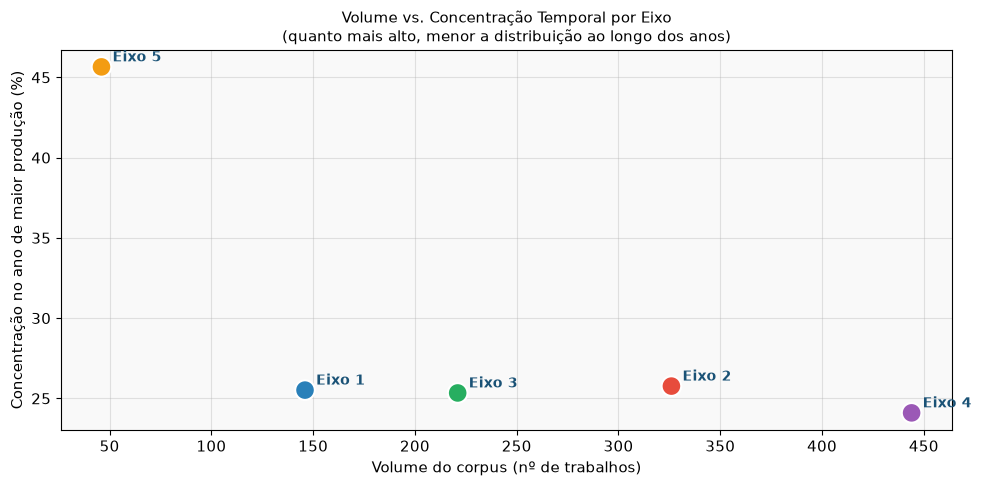

In [16]:
LACUNAS = {
    'Eixo 1\n(mediação)': (
        "Escassez de estudos que articulem mediação pedagógica E linguística de forma integrada "
        "no contexto bilíngue. A produção tende a tratar as duas dimensões de forma separada."
    ),
    'Eixo 2\n(prof./intérp.)': (
        "Poucos estudos investigam especificamente as PRÁTICAS COLABORATIVAS entre professor e "
        "intérprete na EPT/Institutos Federais. A maioria aborda a Educação Básica regular."
    ),
    'Eixo 3\n(colaboração)': (
        "Carência de estudos sobre coplanejamento sistemático e organização compartilhada de "
        "referências conceituais entre professor e intérprete como unidade de análise."
    ),
    'Eixo 4\n(tecnologias)': (
        "A produção está concentrada em tradução automática e glossários de Libras. "
        "Há escassez de ambientes digitais voltados à MEDIAÇÃO CONCEITUAL bilíngue colaborativa."
    ),
    'Eixo 5\n(EPT)': (
        "Volume muito reduzido de produção sobre surdos/TILS especificamente nos Institutos "
        "Federais. Subcampo emergente, com poucas referências para orientar práticas institucionais."
    ),
}

print("SÍNTESE DAS LACUNAS IDENTIFICADAS")
print("=" * 65)
for eixo, lacuna in LACUNAS.items():
    n = df_corpus['Eixo'].str.contains(eixo.split('\n')[0], regex=False, na=False).sum()
    print(f"\n{eixo.replace(chr(10),' ')} ({n} trabalhos):")
    # Quebrar texto
    palavras = lacuna.split()
    linha, linhas = "", []
    for p in palavras:
        if len(linha) + len(p) + 1 > 75:
            linhas.append(linha)
            linha = p
        else:
            linha = (linha + " " + p).strip()
    if linha: linhas.append(linha)
    print("  → " + "\n    ".join(linhas))

# Gráfico de lacunas - volume × concentração temporal
fig, ax = plt.subplots(figsize=(10, 5))
ns   = [df_corpus['Eixo'].str.contains(e, regex=False, na=False).sum() for e in EIXOS]
# % concentrado no eixo com maior produção em apenas 1 ano
def concentracao(e):
    s = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    s = s[(s['Ano'] >= 2020) & (s['Ano'] <= 2025)]
    if len(s) == 0: return 0
    return s.groupby('Ano').size().max() / len(s) * 100

conc = [concentracao(e) for e in EIXOS]
scatter = ax.scatter(ns, conc, s=200, c=PAL[:5], zorder=5, edgecolors='white', linewidth=1.5)
for e, n, c in zip(EIXOS, ns, conc):
    ax.annotate(e, (n, c), textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold', color=ACCENT)
ax.set_xlabel('Volume do corpus (nº de trabalhos)', fontsize=11)
ax.set_ylabel('Concentração no ano de maior produção (%)', fontsize=11)
ax.set_title('Volume vs. Concentração Temporal por Eixo\n'
             '(quanto mais alto, menor a distribuição ao longo dos anos)', fontsize=11)
plt.tight_layout()
plt.savefig('data/fig_lacunas.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Síntese do Estado da Arte


In [17]:
# Tabela síntese - sem scores, apenas dados bibliométricos e analíticos
dados_sintese = []
for e in EIXOS:
    sub = df_corpus[df_corpus['Eixo'].str.contains(e, regex=False, na=False)]
    n = len(sub)
    diss = (sub['Tipo']=='Dissertação').sum()
    tese = (sub['Tipo']=='Tese').sum()
    ano_sub = sub[(sub['Ano']>=2020)&(sub['Ano']<=2025)]
    ano_pico = int(ano_sub.groupby('Ano').size().idxmax()) if len(ano_sub) else '-'
    dados_sintese.append({
        'Eixo': e,
        'Trabalhos': n,
        'Diss.': diss,
        'Teses': tese,
        'Ano pico': ano_pico,
        'Multi-eixo': sub['Eixo'].str.contains('|', regex=False, na=False).sum(),
    })

df_sint = pd.DataFrame(dados_sintese)
print("TABELA SÍNTESE DO CORPUS POR EIXO TEMÁTICO")
print("=" * 62)
print(df_sint.to_string(index=False))
print()

# Alinhamento com os objetivos específicos
print()
print("RELAÇÃO ENTRE EIXOS E OBJETIVOS ESPECÍFICOS DA PESQUISA")
print("=" * 62)
objs = [
    ("Obj. Esp. 1",
     "Caracterizar práticas colaborativas professor-intérprete na EPT",
     "Eixo 2 (núcleo) + Eixo 3",
     f"{df_corpus['Eixo'].str.contains('Eixo 2', na=False).sum() + df_corpus['Eixo'].str.contains('Eixo 3', na=False).sum()} trabalhos; lacuna: práticas específicas na EPT/IF"),
    ("Obj. Esp. 2",
     "Identificar desafios e necessidades na relação professor-intérprete",
     "Eixo 2 + Eixo 1",
     f"{df_corpus['Eixo'].str.contains('Eixo 2', na=False).sum()} trabalhos; base em Lacerda (2006), Silva et al. (2023)"),
    ("Obj. Esp. 3",
     "Desenvolver o Ambiente Bilíngue de Mediação Conceitual (PE)",
     "Eixo 4 + Eixo 3",
     f"{df_corpus['Eixo'].str.contains('Eixo 4', na=False).sum()} trabalhos; lacuna: ambientes bilíngues de mediação conceitual"),
    ("Obj. Esp. 4",
     "Compreender potencialidades e limites do PE",
     "Eixo 4 + Eixo 5",
     f"{df_corpus['Eixo'].str.contains('Eixo 5', na=False).sum()} trabalhos; subcampo emergente na EPT"),
]
for cod, obj, eixos_rel, nota in objs:
    print(f"\n{cod}: {obj}")
    print(f"  Eixos relacionados: {eixos_rel}")
    print(f"  Nota: {nota}")


# Tabela de sintese completa formatada para copiar
print()
print("TABELA SINTESE COMPLETA")
print("=" * 75)
header_s = f"{'Eixo':<8} {'n':>5} {'Diss.':>6} {'Teses':>6} {'Ano pico':>9} {'Multi-eixo':>11}"
print(header_s)
print("-" * 75)
for d in dados_sintese:
    print(f"  {d['Eixo']:<8} {d['Trabalhos']:>5} {d['Diss.']:>6} {d['Teses']:>6} {str(d['Ano pico']):>9} {d['Multi-eixo']:>11}")
print("-" * 75)
total_multi = sum(d['Multi-eixo'] for d in dados_sintese)
print(f"  {'TOTAL':<8} {n_corpus:>5} {sum(d['Diss.'] for d in dados_sintese):>6} {sum(d['Teses'] for d in dados_sintese):>6} {'':>9} {total_multi:>11}")
print()
print("Nota: um trabalho pode aparecer em mais de um eixo (registros com multiplos eixos).")


TABELA SÍNTESE DO CORPUS POR EIXO TEMÁTICO
  Eixo  Trabalhos  Diss.  Teses  Ano pico  Multi-eixo
Eixo 1        146    112     34      2021          84
Eixo 2        326    266     60      2023         179
Eixo 3        221    153     68      2022         123
Eixo 4        444    356     88      2022         163
Eixo 5         46     46      0      2023          30


RELAÇÃO ENTRE EIXOS E OBJETIVOS ESPECÍFICOS DA PESQUISA

Obj. Esp. 1: Caracterizar práticas colaborativas professor-intérprete na EPT
  Eixos relacionados: Eixo 2 (núcleo) + Eixo 3
  Nota: 547 trabalhos; lacuna: práticas específicas na EPT/IF

Obj. Esp. 2: Identificar desafios e necessidades na relação professor-intérprete
  Eixos relacionados: Eixo 2 + Eixo 1
  Nota: 326 trabalhos; base em Lacerda (2006), Silva et al. (2023)

Obj. Esp. 3: Desenvolver o Ambiente Bilíngue de Mediação Conceitual (PE)
  Eixos relacionados: Eixo 4 + Eixo 3
  Nota: 444 trabalhos; lacuna: ambientes bilíngues de mediação conceitual

Obj. Esp. 4: C

## 8. Considerações Finais

O levantamento bibliográfico realizado - com protocolo sistemático de busca, critérios explícitos de inclusão e exclusão definidos previamente e triagem temática por leitura de títulos e resumos - resultou em um corpus de **866 teses e dissertações** distribuídas em cinco eixos temáticos, a partir de **2.618 registros brutos** recuperados nas bases BDTD/IBICT e no Catálogo de Teses e Dissertações da CAPES. A classificação temática por eixo foi realizada manualmente pelo pesquisador, com critérios estabelecidos *a priori* e descritos na Seção 1.2.

### O que o estado da arte revela

**1. Produção consolidada, mas com assimetrias reveladoras:**
Os Eixos 2 (professor/intérprete, n=326) e 4 (tecnologias, n=444) concentram o maior volume do corpus, indicando que esses temas já alcançaram maturidade na Pós-Graduação brasileira. O Eixo 5 (EPT, n=46), em contraste, revela produção ainda incipiente - assimetria que não é acidental, mas reflexo da histórica subrepresentação dos Institutos Federais como campo específico de investigação nos estudos sobre educação de surdos.

**2. Lacuna central confirmada e delimitada:**
A análise cruzada dos eixos confirma que nenhum trabalho do corpus articula simultaneamente as três dimensões centrais desta investigação: *práticas colaborativas professor-intérprete* + *contexto da EPT/Institutos Federais* + *ambiente digital de mediação conceitual bilíngue*. Esse vazio não apenas justifica a pesquisa - ele a orienta: a lacuna é suficientemente específica para ser tratável em nível de mestrado e suficientemente relevante para produzir conhecimento original sobre um subcampo emergente, confirmando a **originalidade do problema de pesquisa formulado**.

**3. O que a literatura investiga e o que ela ainda não investiga - dimensão qualitativa:**
A análise do perfil metodológico por eixo (Seção 5.1) revela que o estudo de caso domina nos eixos de mediação e professor/intérprete - o que indica que o fenômeno é investigado em suas manifestações particulares, sem proposta de instrumento replicável. A pesquisa-ação, mais frequente nos eixos de colaboração e EPT, sugere que nesses campos os pesquisadores já reconhecem a necessidade de *intervir* para compreender - o que alinha esta investigação à abordagem metodológica adotada.

A análise dos sujeitos confirma outra tendência: a díade professor-intérprete raramente é constituída como unidade central de análise. A maioria das pesquisas mantém o aluno surdo como sujeito principal ou co-principal, tratando professor e intérprete como contexto ou condição da aprendizagem - não como fenômeno em si. Este trabalho inverte esse enquadramento ao eleger a *relação de trabalho* entre professor e intérprete como objeto.

**4. Pertinência do referencial teórico:**
A produção dos Eixos 1 e 2 valida o diálogo com Vigotski (2009), Saviani (2011) e Lacerda (2006): esses autores figuram entre as referências e palavras-chave dos trabalhos mais próximos ao objeto desta investigação, confirmando que o referencial adotado não é arbitrário - é o mais mobilizado pelo campo para tratar de mediação em contextos bilíngues.

**5. Fundamentação empírica do Produto Educacional:**
O Eixo 4 (444 trabalhos) documenta um padrão consistente: a quase totalidade das soluções tecnológicas mapeadas está concentrada em tradução automática, glossários de Libras e recursos de acessibilidade individuais. Ambientes digitais voltados à *mediação conceitual colaborativa* - nos quais professor e intérprete atuam conjuntamente como co-autores do processo pedagógico - permanecem ausentes na literatura levantada. Essa lacuna específica fundamenta e orienta a proposição do Ambiente Bilíngue de Mediação Conceitual (Português/Libras) como Produto Educacional.

**6. Trabalhos com maior integração temática:**
Os 262 trabalhos classificados em múltiplos eixos (≈30% do corpus) representam a produção com maior aderência ao objeto desta pesquisa. Sua análise transversal, realizada na Seção 5, evidencia que a integração entre mediação pedagógica, colaboração professor-intérprete e tecnologias ainda é pouco explorada na literatura nacional - reforçando a pertinência e a necessidade da abordagem multidimensional adotada nesta investigação.

---

### Limitações metodológicas do levantamento

Este estado da arte apresenta limitações que devem ser explicitadas:

1. **Escopo das bases:** a busca foi restrita à BDTD e ao Catálogo CAPES, que cobrem a produção brasileira de pós-graduação. Literatura internacional, periódicos e anais de eventos não foram incluídos - delimitação intencional, coerente com o foco em práticas e políticas nacionais de inclusão na EPT.

2. **Período de cobertura:** o recorte 2020–2026 privilegia a produção recente, em detrimento de trabalhos anteriores que podem ter estabelecido bases teóricas ainda relevantes. Referências anteriores a 2020 (como Lacerda, 2006) são incorporadas no referencial teórico da dissertação, não neste levantamento.

3. **Classificação manual:** a atribuição de eixos resulta de leitura interpretativa do pesquisador e, portanto, carrega subjetividade inerente. Os critérios descritos na Seção 1.2 buscam maximizar a transparência e a replicabilidade da classificação.

4. **Cobertura dos campos analíticos:** os campos qualitativos (tipo de estudo, sujeitos, tecnologia empregada) foram preenchidos parcialmente durante o processo de triagem; a análise da Seção 5.1 reflete os registros classificados, não o corpus completo.

---

### Nota sobre o instrumento de análise

Este notebook constitui o **script de mineração e visualização de dados** utilizado nesta pesquisa - não uma fonte bibliográfica de revisão de literatura. O conjunto de dados e este instrumento são disponibilizados como **dados suplementares** da pesquisa, seguindo princípios de Ciência Aberta e reprodutibilidade.¹

---

### Referências

BRASIL. Coordenação de Aperfeiçoamento de Pessoal de Nível Superior (CAPES). *Catálogo de Teses e Dissertações*. Brasília: CAPES. Disponível em: https://catalogodeteses.capes.gov.br/. Acesso em: 6 jul. 2026.

INSTITUTO BRASILEIRO DE INFORMAÇÃO EM CIÊNCIA E TECNOLOGIA (IBICT). *Biblioteca Digital Brasileira de Teses e Dissertações (BDTD)*. Brasília: IBICT, [2002?]. Disponível em: https://bdtd.ibict.br/vufind/. Acesso em: 6 jul. 2026.


---
> ¹ Dados suplementares: QUEIROZ, M. A. *ProfEPT: estado da arte - dados e script de análise*. Anápolis: IFG, 2026. Disponível em: https://marcoantonioq.github.io/profept/arte/. Acesso em: 6 jul. 2026.